In [1]:
#!pip install rocketpy
#pip install pandas

In [2]:
from rocketpy import *
import datetime
import inspect
import traceback
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

In [3]:
import types
from rocketpy.sensors.accelerometer import Accelerometer
from rocketpy.mathutils.vector_matrix import Vector, Matrix

# ---------------------------------------------------------
# ROCKETPY PHYSICS BUG PATCH
# ---------------------------------------------------------
# RocketPy's accelerometer.py mathematically models the IMU load 
# with the bug: a_sensor = a_kinematic + gravity
# This monkey-patch replaces the measure function at runtime 
# to use the correct equation: a_sensor = a_kinematic - gravity
# ---------------------------------------------------------
def patched_measure(self, time, **kwargs):
    u = kwargs['u']
    u_dot = kwargs['u_dot']
    relative_position = kwargs['relative_position']
    gravity = kwargs['environment'].gravity.get_value_opt(u[3])
    
    gravity = Vector([0, 0, -gravity]) if self.consider_gravity else Vector([0, 0, 0])
    # THE FIX: '-' gravity instead of '+' gravity
    inertial_acceleration = Vector(u_dot[3:6]) - gravity
    
    r = relative_position
    omega = Vector(u[10:13])
    omega_dot = Vector(u_dot[10:13])
    
    A = (inertial_acceleration + Vector.cross(omega_dot, r) + 
         Vector.cross(omega, Vector.cross(omega, r)))
         
    inertial_to_sensor = (self._total_rotation_sensor_to_body @ Matrix.transformation(u[6:10]).transpose)
    A = inertial_to_sensor @ A
    
    A = self.apply_noise(A)
    A = self.apply_temperature_drift(A)
    A = self.quantize(A)
    
    self.measurement = tuple([*A])
    self._save_data((time, *A))

Accelerometer.measure = patched_measure
print('RocketPy Accelerometer physics bug successfully patched!')

RocketPy Accelerometer physics bug successfully patched!



Gravity Details

Acceleration of gravity at surface level:    9.7913 m/s²
Acceleration of gravity at  13.932 km (ASL): 9.7528 m/s²


Launch Site Details

Launch Date: 2025-02-02 14:00:00 UTC
Launch Site Latitude: 32.99025°
Launch Site Longitude: -106.97500°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 315468.64 W    3651938.65 N
Launch Site UTM zone: 13S
Launch Site Surface Elevation: 1411.0 m


Atmospheric Model Details

Atmospheric Model Type: Windy
Windy Maximum Height: 13.932 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.51 m/s
Surface Wind Direction: 120.58°
Surface Wind Heading: 300.58°
Surface Pressure: 862.32 hPa
Surface Temperature: 287.85 K
Surface Air Density: 1.044 kg/m³
Surface Speed of Sound: 340.12 m/s


Earth Model Details

Earth Radius at Launch site: 6371.83 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



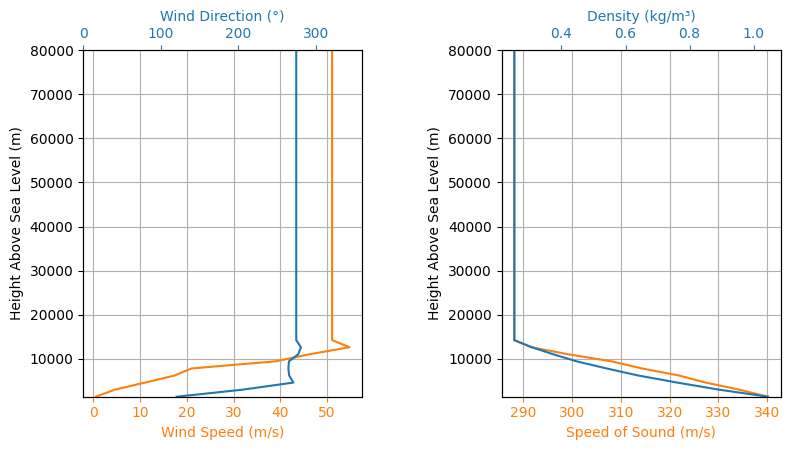

In [4]:
env = Environment(latitude=32.990254, longitude=-106.974998, elevation=1400)
tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env.set_date(
    (2025, 2, 2, 14)
)  # Hour given in UTC time
env.set_atmospheric_model(type="Windy", file="GFS")

env.info()

In [5]:
# Define the fluids
oxidizer_liq = Fluid(name="N2O_l", density=880)
oxidizer_gas = Fluid(name="N2O_g", density=111)

# Define tank geometry
tank_shape = CylindricalTank(128.2 / 2000, 0.600)

oxidizer_tank = MassBasedTank(
    name = "TANKAO",
    geometry=tank_shape,
    flux_time=(13.44),
    liquid=oxidizer_liq,
    liquid_mass='nelore_liquid_mass.csv',
    gas=oxidizer_gas,
    gas_mass='nelore_vapor_mass.csv'
)

Nelore = HybridMotor(
    thrust_source='nelore_static_fire.csv',
    dry_mass=0,
    dry_inertia=(0, 0, 0),
    center_of_dry_mass_position=0,
    burn_time=13.684,
    reshape_thrust_curve=False,
    grain_number=1,
    grain_separation=0,
    grain_outer_radius= 98 / 2000,
    grain_initial_inner_radius=0.05 / 2,
    grain_initial_height= 320 / 1000,
    grain_density=900,
    nozzle_radius=63.36 / 2000,
    throat_radius=26 / 2000,
    interpolation_method="linear",
    grains_center_of_mass_position=299/1000,
    nozzle_position=0,
    coordinate_system_orientation="nozzle_to_combustion_chamber"
)

Nelore.add_tank(
  tank = oxidizer_tank, position = 1017/1000
)

C:\Users\Fefon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rocketpy\motors\motor.py:990: UserWarning: burn_time argument (0, 13.684) is out of thrust source time range. Using thrust_source boundary times instead: (0, 13.44) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


In [6]:
pacifico = Rocket(
    radius= 0.0817,
    mass= 13.5 + 11.605 + 2.5 + 3,
    #mass= 34.112, #massa para 3km
    inertia=(13.383, 13.383, 0.161),
    power_off_drag= 'spaceshotCD00.csv',
    power_on_drag= 'spaceshotCD00.csv',
    center_of_mass_without_motor=1.046,
    coordinate_system_orientation="tail_to_nose",
)

pacifico_Controlled = Rocket(
    radius= 0.0817,
    mass= 13.5 + 11.605 + 2.5 + 3,
    inertia=(13.383, 13.383, 0.161),
    power_off_drag= 'spaceshotCD00.csv',
    power_on_drag= 'spaceshotCD00.csv',
    center_of_mass_without_motor=1.046,
    coordinate_system_orientation="tail_to_nose",
)

rail_buttons = pacifico.set_rail_buttons(
    upper_button_position=1.038, #1.037
    lower_button_position=0.060,
    angular_position=45,
)

pacifico.add_motor(Nelore, position=0)

NACA0012_TRUNCADO =Function([[0,0.0002],[2,0.3320],[4,0.6335],[6,0.6877]])

nose_cone = pacifico.add_nose(
      length=0.650, kind="vonKarman", position=2.70105
    )

fin_set = pacifico.add_trapezoidal_fins(
    n=4,
    root_chord=0.230,
    tip_chord=0.150,
    span=0.210,
    position=0.30905,
    cant_angle=0.5,
    airfoil=(NACA0012_TRUNCADO, "degrees"),
    sweep_length=0.080,
)

tail = pacifico.add_tail(
    top_radius=0.0817, bottom_radius=0.0695, length=0.035, position=0.02805
)

rail_buttons = pacifico_Controlled.set_rail_buttons(
    upper_button_position=1.038, #1.037
    lower_button_position=0.060,
    angular_position=45,
)

pacifico_Controlled.add_motor(Nelore, position=0)

NACA0012_TRUNCADO =Function([[0,0.0002],[2,0.3320],[4,0.6335],[6,0.6877]])

nose_cone = pacifico_Controlled.add_nose(
      length=0.650, kind="vonKarman", position=2.70105
    )

fin_set = pacifico_Controlled.add_trapezoidal_fins(
    n=4,
    root_chord=0.230,
    tip_chord=0.150,
    span=0.210,
    position=0.30905,
    cant_angle=0.5,
    airfoil=(NACA0012_TRUNCADO, "degrees"),
    sweep_length=0.080,
)

tail = pacifico_Controlled.add_tail(
    top_radius=0.0817, bottom_radius=0.0695, length=0.035, position=0.02805
)

In [7]:
import numpy as np
from rocketpy.mathutils import Vector
from rocketpy.sensors import InertialSensor

def apply_noise_compact(self, value):
    """
    Add noise to the sensor measurement

    Parameters
    ----------
    value : float
        The value to add noise to

    Returns
    -------
    float
        The value with added noise
    """
    fs_root = self.sampling_rate ** 0.5
    
    get = lambda x: x if hasattr(x, '__getitem__') else [x] * 3
    # prepare params
    nv, nd = get(self.noise_variance), get(self.noise_density)

    # white noise
    white_noise = Vector([
        np.random.normal(0, np.sqrt(nv[i] + (nd[i] * fs_root)**2)) for i in range(3)
    ])

    # random walk
    rwv = get(getattr(self, 'random_walk_variance', 0))
    rwd = get(getattr(self, 'random_walk_density', 0))

    self._random_walk_drift += Vector([
        np.random.normal(0, np.sqrt(rwv[i] + (rwd[i] * fs_root)**2)) for i in range(3)
    ])

    # add noise
    value += white_noise + self._random_walk_drift + self.constant_bias

    return value

InertialSensor.apply_noise = apply_noise_compact


import numpy as np
from rocketpy.sensors import ScalarSensor

def apply_noise_scalar_compact(self, value):
    """
    Versão corrigida para sensores Escalares (Barômetro).
    Modelo: Sigma = sqrt(Variance + (Density * sqrt(Fs))^2)
    """
    fs_root = self.sampling_rate ** 0.5
    
     # white noise
    sigma = np.sqrt(self.noise_variance + (self.noise_density * fs_root)**2)
    white_noise = np.random.normal(0, sigma)

    # random walk
    sigma_rw = np.sqrt(self.random_walk_variance + (self.random_walk_density * fs_root)**2)
    self._random_walk_drift += np.random.normal(0, sigma_rw)

    # add noise
    value += white_noise + self._random_walk_drift + self.constant_bias
    return value 

ScalarSensor.apply_noise = apply_noise_scalar_compact

In [8]:
from rocketpy.mathutils import Matrix, Vector
from rocketpy.sensors import InertialSensor


class Magnetometer(InertialSensor):
    """Class for the magnetometer sensor

    Attributes
    ----------
    magnetic_field : Vector
        The reference magnetic field vector in the inertial frame (Tesla).
    soft_iron_matrix : Matrix
        The soft iron distortion matrix (3x3).
    sampling_rate : float
        Sample rate of the sensor in Hz.
    orientation : tuple, list
        Orientation of the sensor in the rocket.
    measurement_range : float, tuple
        The measurement range of the sensor in Tesla.
    resolution : float
        The resolution of the sensor in T/LSB.
    noise_density : float, list
        The noise density of the sensor in T/√Hz.
    noise_variance : float, list
        The variance of the noise of the sensor in T^2.
    random_walk_density : float, list
        The random walk density of the sensor in T/√Hz.
    random_walk_variance : float, list
        The random walk variance of the sensor in T^2.
    constant_bias : float, list
        The constant bias of the sensor in Tesla.
    operating_temperature : float
        The operating temperature of the sensor in Kelvin.
    temperature_bias : float, list
        The temperature bias of the sensor in T/K.
    temperature_scale_factor : float, list
        The temperature scale factor of the sensor in %/K.
    cross_axis_sensitivity : float
        The cross axis sensitivity of the sensor in percentage.
    name : str
        The name of the sensor.
    rotation_sensor_to_body : Matrix
        The rotation matrix of the sensor from the sensor frame to the rocket
        frame of reference.
    normal_vector : Vector
        The normal vector of the sensor in the rocket frame of reference.
    _random_walk_drift : Vector
        The random walk drift of the sensor in Tesla.
    measurement : tuple
        The measurement of the sensor after quantization, noise, and temperature
        drift.
    measured_data : list
        The stored measured data of the sensor after quantization, noise, and
        temperature drift.
    """

    units = "T"

    def __init__(
        self,
        sampling_rate,
        magnetic_field,
        orientation=(0, 0, 0),
        measurement_range=np.inf,
        resolution=0,
        noise_density=0,
        noise_variance=0,
        random_walk_density=0,
        random_walk_variance=0,
        operating_temperature=298.15,
        temperature_bias=0,
        temperature_scale_factor=0,
        cross_axis_sensitivity=0,
        constant_bias=(0, 0, 0),    # Vetor (x, y, z) em Tesla
        soft_iron_matrix=None,      # Matriz 3x3 de distorção
        name="Magnetometer",
    ):
        """
        Initialize the magnetometer sensor

        Parameters
        ----------
        sampling_rate : float
            Sample rate of the sensor in Hz.
        magnetic_field : tuple, list, Vector
            The reference magnetic field vector in the inertial frame in Tesla.
            Example: (20e-6, 0, 40e-6).
        orientation : tuple, list, optional
            Orientation of the sensor in the rocket. The orientation can be
            given as:

            - A list of length 3, where the elements are the Euler angles for
              the rotation yaw (ψ), pitch (θ) and roll (φ) in radians. The
              standard rotation sequence is z-y-x (3-2-1) is used, meaning the
              sensor is first rotated by ψ around the x axis, then by θ around
              the new y axis and finally by φ around the new z axis.
            - A list of lists (matrix) of shape 3x3, representing the rotation
              matrix from the sensor frame to the rocket frame. The sensor frame
              of reference is defined as to have z axis along the sensor's normal
              vector pointing upwards, x and y axes perpendicular to the z axis
              and each other.

            The rocket frame of reference is defined as to have z axis
            along the rocket's axis of symmetry pointing upwards, x and y axes
            perpendicular to the z axis and each other. Default is (0, 0, 0),
            meaning the sensor is aligned with the rocket's axis of symmetry.
        measurement_range : float, tuple, optional
            The measurement range of the sensor in Tesla. If a float, the
            same range is applied both for positive and negative values. If a
            tuple, the first value is the positive range and the second value is
            the negative range. Default is np.inf.
        resolution : float, optional
            The resolution of the sensor in T/LSB. Default is 0, meaning no
            quantization is applied.
        noise_density : float, list, optional
            The noise density of the sensor for a Gaussian white noise in T/√Hz.
            Default is 0, meaning no noise is applied. If a float or int is
            given, the same noise density is applied to all axes. The values of
            each axis can be set individually by passing a list of length 3.
        noise_variance : float, list, optional
            The noise variance of the sensor for a Gaussian white noise in T^2.
            Default is 0, meaning no noise is applied. If a float or int is
            given, the same variance is applied to all axes. The values of each
            axis can be set individually by passing a list of length 3.
        random_walk_density : float, list, optional
            The random walk density of the sensor for a Gaussian random walk in
            T/√Hz. Default is 0, meaning no random walk is applied. If a float
            or int is given, the same random walk is applied to all axes. The
            values of each axis can be set individually by passing a list of
            length 3.
        random_walk_variance : float, list, optional
            The random walk variance of the sensor for a Gaussian random walk in
            T^2. Default is 0, meaning no random walk is applied. If a float
            or int is given, the same variance is applied to all axes. The
            values of each axis can be set individually by passing a list of
            length 3.
        operating_temperature : float, optional
            The operating temperature of the sensor in Kelvin.
            At 298.15 K (25 °C), the sensor is assumed to operate ideally, no
            temperature related noise is applied. Default is 298.15.
        temperature_bias : float, list, optional
            The temperature bias of the sensor in T/K. Default is 0,
            meaning no temperature bias is applied. If a float or int is given,
            the same temperature bias is applied to all axes. The values of each
            axis can be set individually by passing a list of length 3.
        temperature_scale_factor : float, list, optional
            The temperature scale factor of the sensor in %/K. Default is 0,
            meaning no temperature scale factor is applied. If a float or int is
            given, the same temperature scale factor is applied to all axes. The
            values of each axis can be set individually by passing a list of
            length 3.
        cross_axis_sensitivity : float, optional
            Skewness of the sensor's axes in percentage. Default is 0, meaning
            no cross-axis sensitivity is applied.
        constant_bias : float, list, optional
            The constant bias of the sensor in Tesla. This is used to model
            Hard Iron distortion. Default is (0, 0, 0).
        soft_iron_matrix : list, Matrix, optional
            The soft iron distortion matrix (3x3). Applied to the magnetic field
            vector to simulate soft iron effects. Default is identity matrix.
        name : str, optional
            The name of the sensor. Default is "Magnetometer".

        Returns
        -------
        None
        """
        # O Hard Iron é tratado como o bias constante  do sensor
        super().__init__(
            sampling_rate=sampling_rate,
            orientation=orientation,
            measurement_range=measurement_range,
            resolution=resolution,
            noise_density=noise_density,
            noise_variance=noise_variance,
            random_walk_density=random_walk_density,
            random_walk_variance=random_walk_variance,
            constant_bias=constant_bias, 
            operating_temperature=operating_temperature,
            temperature_bias=temperature_bias,
            temperature_scale_factor=temperature_scale_factor,
            cross_axis_sensitivity=cross_axis_sensitivity,
            name=name,
        )
        
        # Configura o campo magnético de referência 
        if isinstance(magnetic_field, (tuple, list)):
            self.magnetic_field = Vector(magnetic_field)
        else:
            self.magnetic_field = magnetic_field

        # Configura Matriz de Soft Iron 
        if soft_iron_matrix is None:
            # Identidade: sem distorção
            self.soft_iron_matrix = Matrix([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
        else:
            self.soft_iron_matrix = Matrix(soft_iron_matrix)

    def measure(self, time, **kwargs):
        """Measure the magnetic field vector

        Parameters
        ----------
        time : float
            Current time in seconds.
        kwargs : dict
            Keyword arguments dictionary containing the following keys:

            - u : np.array
                State vector of the rocket.
        """
        u = kwargs["u"] 

        B_inertial = Vector(self.magnetic_field)
        inertial_to_body = Matrix.transformation(u[6:10]).transpose
        inertial_to_sensor = self._total_rotation_sensor_to_body @ inertial_to_body
        
        B_ideal = inertial_to_sensor @ B_inertial

        B_ideal_np = np.array([B_ideal[0], B_ideal[1], B_ideal[2]])
        
        B_distorted_np = np.array(self.soft_iron_matrix) @ B_ideal_np

        B_distorted_vec = Vector(B_distorted_np)

        B_final = self.apply_noise(B_distorted_vec)
        B_final = self.apply_temperature_drift(B_final)
        B_final = self.quantize(B_final)

        self.measurement = tuple([*B_final])
        self._save_data((time, *B_final))

    def export_measured_data(self, filename, file_format="csv"):
        """Export the measured values to a file

        Parameters
        ----------
        filename : str
            Name of the file to export the values to
        file_format : str
            file_Format of the file to export the values to. Options are "csv" and
            "json". Default is "csv".

        Returns
        -------
        None
        """
        self._generic_export_measured_data(
            filename=filename,
            file_format=file_format,
            data_labels=("t", "Bx", "By", "Bz"),
        )
        
    def to_dict(self, **kwargs):
        data = super().to_dict(**kwargs)
        data.update({
            "magnetic_field": [self.magnetic_field.x, self.magnetic_field.y, self.magnetic_field.z],
            "soft_iron_matrix": self.soft_iron_matrix.tolist() if hasattr(self.soft_iron_matrix, 'tolist') else self.soft_iron_matrix
        })
        return data

    @classmethod
    def from_dict(cls, data):
        return cls(
            sampling_rate=data["sampling_rate"],
            magnetic_field=data["magnetic_field"],
            orientation=data["orientation"],
            measurement_range=data["measurement_range"],
            resolution=data["resolution"],
            noise_density=data["noise_density"],
            noise_variance=data["noise_variance"],
            random_walk_density=data["random_walk_density"],
            random_walk_variance=data["random_walk_variance"],
            constant_bias=data["constant_bias"],
            operating_temperature=data["operating_temperature"],
            temperature_bias=data["temperature_bias"],
            temperature_scale_factor=data["temperature_scale_factor"],
            cross_axis_sensitivity=data["cross_axis_sensitivity"],
            soft_iron_matrix=data.get("soft_iron_matrix"),
            name=data["name"],
        )

In [9]:
def get_sensor_calibration(file_path, fs=50.0, gyro_unit_is_deg=True, calculate_mag_bias=False, reference_mag_field_T=None):
    """
    Analisa um log estático de sensores, imprime um relatório detalhado em unidades SI
    e retorna um dicionário formatado para instanciar sensores no RocketPy.
    
    Argumentos:
        file_path (str): Caminho do arquivo CSV.
        fs (float): Frequência de amostragem em Hz.
        gyro_unit_is_deg (bool): Se True, converte entrada de Graus -> Radianos.
        calculate_mag_bias (bool): Se True, calcula o Bias subtraindo o campo de referência da média medida.
        reference_mag_field_T (tuple): Vetor do campo magnético da Terra (X, Y, Z) em TESLA 
                                     esperado para a orientação em que o sensor estava.
    
    Retorna:
        dict: Dicionário contendo chaves 'gyro', 'accel', 'mag', 'baro'.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"✅ Arquivo carregado: {file_path}")
    except:
        print(f"❌ Erro ao ler arquivo: {file_path}")
        return None

    # Dicionário de retorno
    config = {}

    # --- Funções Auxiliares de Formatação e Cálculo ---
    def fmt_vec(v): 
        return f"[{v[0]:.3e}, {v[1]:.3e}, {v[2]:.3e}]"

    def calc_rw_vec(data, fs):
        n = int(len(data)/fs)
        if n < 5: return np.zeros(3)
        rw_list = []
        for i in range(3):
            means = [np.mean(w) for w in np.array_split(data[:, i], n)]
            rw_list.append( (np.std(means) / np.sqrt(n))**2 )
        return np.array(rw_list)

    def calc_rw_scalar(data, fs):
        n = int(len(data)/fs)
        if n < 5: return 0.0
        means = [np.mean(w) for w in np.array_split(data, n)]
        return (np.std(means) / np.sqrt(n))**2

    print("\n" + "="*70)
    print(f"   RELATÓRIO DE CALIBRAÇÃO ESTÁTICA (Fs={fs}Hz)")
    print("="*70)

    # ---------------------------------------------------------
    # 1. GIROSCÓPIO
    # ---------------------------------------------------------
    gyro_cols = [c for c in df.columns if 'Gyr' in c]
    if len(gyro_cols) == 3:
        g_vals = df[gyro_cols].values
        
        # Conversão de Unidade
        suffix = "rad/s"
        if gyro_unit_is_deg:
            g_vals = np.deg2rad(g_vals)
            print(f"-> Gyro convertido de deg/s para rad/s")
        
        # Estatísticas
        g_bias = np.mean(g_vals, axis=0)
        g_noise = g_vals - g_bias
        g_var = np.var(g_noise, axis=0)
        g_rw = calc_rw_vec(g_noise, fs)

        # Print
        print(f"\n# --- Gyroscope ({suffix}) ---")
        print(f"  Bias Médio:      {fmt_vec(g_bias)}")
        print(f"  Ruído (Std):     {fmt_vec(np.sqrt(g_var))}")
        print(f"  Noise Variance:  {fmt_vec(g_var)}")
        print(f"  Random Walk Var: {fmt_vec(g_rw)}")

        # Salva no Config
        config['gyro'] = {
            'constant_bias': g_bias.tolist(),
            'noise_variance': g_var.tolist(),
            'random_walk_variance': g_rw.tolist(),
            'sampling_rate': fs
        }

    # ---------------------------------------------------------
    # 2. ACELERÔMETRO
    # ---------------------------------------------------------
    acc_cols = [c for c in df.columns if 'Acc' in c][:3]
    if len(acc_cols) == 3:
        a_vals = df[acc_cols].values
        
        # Conversão G -> m/s²
        if np.max(np.abs(a_vals)) < 15: 
            a_vals *= 9.80665
            print(f"\n-> Accel convertido de G para m/s²")
            
        gravity_ref = np.array([0.0, 0.0, 9.80665])
        a_bias = np.mean(a_vals, axis=0) - gravity_ref
        a_noise = a_vals - np.mean(a_vals, axis=0)
        a_var = np.var(a_noise, axis=0)
        a_rw = calc_rw_vec(a_noise, fs)

        # Print
        print(f"\n# --- Accelerometer (m/s²) ---")
        print(f"  Bias (Ref 1g Z): {fmt_vec(a_bias)}")
        print(f"  Ruído (Std):     {fmt_vec(np.sqrt(a_var))}")
        print(f"  Noise Variance:  {fmt_vec(a_var)}")
        print(f"  Random Walk Var: {fmt_vec(a_rw)}")

        config['accel'] = {
            'constant_bias': a_bias.tolist(),
            'noise_variance': a_var.tolist(),
            # 'random_walk_variance': a_rw.tolist(),
            'random_walk_variance': (0,0,0),
            'sampling_rate': fs
        }

    # ---------------------------------------------------------
    # 3. MAGNETÔMETRO
    # ---------------------------------------------------------
    mag_cols = [c for c in df.columns if 'Mag' in c]
    if len(mag_cols) == 3:
        # mG -> Tesla
        m_vals = df[mag_cols].values * 1e-6 
        m_mean = np.mean(m_vals, axis=0)
        
        # Bias
        if calculate_mag_bias and (reference_mag_field_T is not None):
            ref_vec = np.array(reference_mag_field_T)
            m_bias = m_mean - ref_vec
            bias_msg = f"{fmt_vec(m_bias)}"
        else:
            m_bias = np.zeros(3)
            bias_msg = "[0, 0, 0] (Ignorado)"

        m_noise = m_vals - m_mean
        m_var = np.var(m_noise, axis=0)
        m_rw = calc_rw_vec(m_noise, fs)

        print(f"\n# --- Magnetometer (Tesla) ---")
        print(f"  Média Medida:    {fmt_vec(m_mean)}")
        
        ref_str = fmt_vec(reference_mag_field_T) if reference_mag_field_T is not None else 'None'
        print(f"  Ref. Terra:      {ref_str}")
        
        print(f"  Bias Final (Hard Iron):      {bias_msg}") 
        print(f"  Noise Variance:  {fmt_vec(m_var)}")
        print(f"  Random Walk Var: {fmt_vec(m_rw)}")

        config['mag'] = {
            'constant_bias': m_bias.tolist(),
            'noise_variance': m_var.tolist(),
            # 'random_walk_variance': m_rw.tolist(),
            'random_walk_variance': (0,0,0),
            'sampling_rate': fs
        }

    # ---------------------------------------------------------
    # 4. BARÔMETRO
    # ---------------------------------------------------------
    baro_cols = [c for c in df.columns if 'Press' in c or 'Baro' in c]
    if baro_cols:
        p_val = df[baro_cols[0]].values
        p_mean = np.mean(p_val)
        p_noise = p_val - p_mean
        p_var = np.var(p_noise)
        p_rw = calc_rw_scalar(p_val, fs)

        # Print
        print(f"\n# --- Barometer (Pascal) ---")
        print(f"  Média Local:     {p_mean:.2f} Pa")
        print(f"  Ruído (Std):     {np.sqrt(p_var):.2f} Pa (~{np.sqrt(p_var)/12:.2f} m)")
        print(f"  Noise Variance:  {p_var:.4e}")
        print(f"  Random Walk Var: {p_rw:.4e}")

        config['baro'] = {
            'noise_variance': float(p_var),
            'random_walk_variance': float(p_rw),
            # 'random_walk_variance': 0.0,
            'sampling_rate': fs
        }

    print("\n" + "="*70)
    return config


In [28]:
g0 = 9.80665

# Valores: Norte=17.1uT, Leste=-6.5uT, Down=-15.1uT (Sao Paulo)
mag_earth_munich_T = (20.9e-6, 1.74e-6, 43.1e-6)
mag_earth_sp_T = (17.1e-6, -6.5e-6, -15.1e-6) # Sao Paulo
mag_ref_aligned = np.array([
    -mag_earth_munich_T[0], 
    mag_earth_munich_T[1], 
    mag_earth_munich_T[2]
])


calib_data = get_sensor_calibration(
    r'..\Data_read\REG_VOO\Static_test.csv', 
    fs=50.0,
    calculate_mag_bias=False,           
    reference_mag_field_T=mag_ref_aligned
)

✅ Arquivo carregado: ..\Data_read\REG_VOO\Static_test.csv

   RELATÓRIO DE CALIBRAÇÃO ESTÁTICA (Fs=50.0Hz)
-> Gyro convertido de deg/s para rad/s

# --- Gyroscope (rad/s) ---
  Bias Médio:      [1.870e-03, -1.090e-03, 1.164e-04]
  Ruído (Std):     [7.241e-04, 8.104e-04, 7.088e-04]
  Noise Variance:  [5.243e-07, 6.568e-07, 5.023e-07]
  Random Walk Var: [3.764e-10, 2.150e-10, 1.795e-10]

-> Accel convertido de G para m/s²

# --- Accelerometer (m/s²) ---
  Bias (Ref 1g Z): [-2.159e-03, -3.345e-02, -1.018e-02]
  Ruído (Std):     [6.935e-03, 9.135e-03, 1.284e-02]
  Noise Variance:  [4.809e-05, 8.346e-05, 1.649e-04]
  Random Walk Var: [1.720e-08, 3.230e-08, 1.258e-07]

# --- Magnetometer (Tesla) ---
  Média Medida:    [-1.004e-05, 4.118e-05, 5.430e-05]
  Ref. Terra:      [-2.090e-05, 1.740e-06, 4.310e-05]
  Bias Final (Hard Iron):      [0, 0, 0] (Ignorado)
  Noise Variance:  [8.599e-13, 1.784e-12, 8.287e-13]
  Random Walk Var: [4.609e-16, 1.002e-15, 3.385e-16]

# --- Barometer (Pascal) ---
 

In [ ]:
magnetic_field_mun = (20.9e-6, 1.74e-6, 43.1e-6)
magnetic_field_sp = (17.1e-6, -6.5e-6, -15.1e-6) # Sao Paulo

# --- HIL CONFIGURATION ---
location_selection = "MUN"  # Options: "MUN", "SP"
selected_mag_field = magnetic_field_sp if location_selection == "SP" else magnetic_field_mun

if calib_data:

    bmp280 = Barometer(
        name="BMP280",
        measurement_range=(30000, 110000),
        resolution=0.16, 
        **calib_data['baro'] # Injeta: noise_variance, random_walk_variance, sampling_rate
    )
    
    mpu9250_accel = Accelerometer(
        name="MPU9250 - Accel",
        orientation = (0, 0, 0),    # Physically Z-Up (Raw = +1g on pad)
        measurement_range=16 * g0,
        resolution=(32 * g0) / (2**16),
        consider_gravity=True,
        **calib_data['accel']   # Injeta: bias, noise_variance, random_walk_variance, sampling_rate
    )

    accel_sens_si = (0.1 * np.pi / 180) / 9.80665 # rad/s² per m/s²
    mpu9250_gyro = Gyroscope(
        name="MPU9250 - Gyro",
        orientation=(0, 0, 0),
        measurement_range=np.deg2rad(2000),
        resolution=np.deg2rad(4000) / (2**16),
        acceleration_sensitivity=accel_sens_si, # Do datasheet
        **calib_data['gyro'] # Injeta: bias, noise_variance, random_walk_variance, sampling_rate
    )

    mpu9250_mag = Magnetometer(
            name="MPU9250 - Mag",
            orientation=(0, 180, 0),
            measurement_range=4800e-6,
            resolution=0.6e-6,
            magnetic_field= selected_mag_field,
            **calib_data['mag']  # Injeta: bias, noise_variance, random_walk_variance, sampling_rate, magnetic_field
    )


def fmt_vec(v, scale=1.0, fmt=".2e"):
    """
    Formata vetor com segurança, convertendo tipos do RocketPy (Vector)
    para Arrays NumPy antes de processar.
    """
    try:
        v_arr = np.array(v, dtype=float)
    except:
        try:
            v_arr = np.array([v[0], v[1], v[2]], dtype=float)
        except:
            return "[Erro de Formatação]"
            
    v_arr = v_arr * scale
    return f"[{v_arr[0]:{fmt}}, {v_arr[1]:{fmt}}, {v_arr[2]:{fmt}}]"

print("\n" + "="*40)
print("      RELATÓRIO DE SENSORES DEFINIDOS")
print("="*40)

# --- 1. BARÔMETRO ---
if 'bmp280' in locals():
    print(f"\n BARÔMETRO: {bmp280.name}")
    print(f"   • Taxa de Amostragem: {bmp280.sampling_rate} Hz")
    print(f"   • Ruído (RMS):        {np.sqrt(bmp280.noise_variance):.2f} Pa")
    print(f"   • Random Walk:        {bmp280.random_walk_variance:.2e}")

# --- 2. ACELERÔMETRO ---
if 'mpu9250_accel' in locals():
    print(f"\n ACELERÔMETRO: {mpu9250_accel.name}")
    print(f"   • Taxa de Amostragem: {mpu9250_accel.sampling_rate} Hz")
    
    a_range = mpu9250_accel.measurement_range
    try:
        val_range = a_range[0]
    except:
        val_range = a_range
    print(f"   • Faixa Dinâmica:     ±{float(val_range)/g0:.1f} g")
    
    acc_bias = np.array(mpu9250_accel.constant_bias)
    acc_noise = np.array(mpu9250_accel.noise_variance)
    
    print(f"   • Bias (mg):          {fmt_vec(acc_bias, scale=1000/g0, fmt='.2f')}")
    print(f"   • Ruído RMS (m/s²):   {fmt_vec(np.sqrt(acc_noise), fmt='.4f')}")

# --- 3. GIROSCÓPIO ---
if 'mpu9250_gyro' in locals():
    print(f"\n GIROSCÓPIO: {mpu9250_gyro.name}")
    print(f"   • Taxa de Amostragem: {mpu9250_gyro.sampling_rate} Hz")
    
    g_range = mpu9250_gyro.measurement_range
    try:
        val_range = g_range[0]
    except:
        val_range = g_range
    print(f"   • Faixa Dinâmica:     ±{np.rad2deg(float(val_range)):.0f} °/s")
    
    gyro_bias = np.array(mpu9250_gyro.constant_bias)
    gyro_noise = np.array(mpu9250_gyro.noise_variance)
    
    print(f"   • Bias (°/s):         {fmt_vec(gyro_bias, scale=180/np.pi, fmt='.3f')}")
    print(f"   • Ruído RMS (°/s):    {fmt_vec(np.sqrt(gyro_noise), scale=180/np.pi, fmt='.3f')}")

# --- 4. MAGNETÔMETRO ---
if 'mpu9250_mag' in locals():
    print(f"\n MAGNETÔMETRO: {mpu9250_mag.name}")
    print(f"   • Taxa de Amostragem: {mpu9250_mag.sampling_rate} Hz")
    
    mag_bias = np.array(mpu9250_mag.constant_bias)
    mag_noise = np.array(mpu9250_mag.noise_variance)
    
    print(f"   • Bias Hard-Iron (µT):{fmt_vec(mag_bias, scale=1e6, fmt='.2f')}")
    print(f"   • Ruído RMS (µT):     {fmt_vec(np.sqrt(mag_noise), scale=1e6, fmt='.4f')}")
    
print("-" * 40 + "\n")

posicao_airbrake = (0,0,0) # x,y,z z = distancia da origem(z centro de massa sem motor)

pacifico.add_sensor(mpu9250_accel, position=posicao_airbrake)
pacifico.add_sensor(mpu9250_gyro, position=posicao_airbrake)
pacifico.add_sensor(mpu9250_mag, position=posicao_airbrake)
pacifico.add_sensor(bmp280, position=posicao_airbrake)
pacifico_Controlled.add_sensor(mpu9250_accel, position=posicao_airbrake)
pacifico_Controlled.add_sensor(mpu9250_gyro, position=posicao_airbrake)
pacifico_Controlled.add_sensor(mpu9250_mag, position=posicao_airbrake)
pacifico_Controlled.add_sensor(bmp280, position=posicao_airbrake)


      RELATÓRIO DE SENSORES DEFINIDOS

 BARÔMETRO: BMP280
   • Taxa de Amostragem: 50.0 Hz
   • Ruído (RMS):        3.52 Pa
   • Random Walk:        9.42e-02

 ACELERÔMETRO: MPU9250 - Accel
   • Taxa de Amostragem: 50.0 Hz
   • Faixa Dinâmica:     ±-16.0 g
   • Bias (mg):          [-0.22, -3.41, -1.04]
   • Ruído RMS (m/s²):   [0.0069, 0.0091, 0.0128]

 GIROSCÓPIO: MPU9250 - Gyro
   • Taxa de Amostragem: 50.0 Hz
   • Faixa Dinâmica:     ±-2000 °/s
   • Bias (°/s):         [0.107, -0.062, 0.007]
   • Ruído RMS (°/s):    [0.041, 0.046, 0.041]

 MAGNETÔMETRO: MPU9250 - Mag
   • Taxa de Amostragem: 50.0 Hz
   • Bias Hard-Iron (µT):[0.00, 0.00, 0.00]
   • Ruído RMS (µT):     [0.9273, 1.3356, 0.9103]
----------------------------------------



C:\Users\Fefon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rocketpy\sensors\sensor.py:120: UserWarning: The Sensor class (and all its subclasses) is still under experimental development. Some features may be changed in future versions, although we will try to keep the changes to a minimum.
  warnings.warn(


Simulando 30.0s de sensores na bancada (50z)...

--- Estatísticas Médias da Simulação ---
Mag X: -20.89 uT 
Mag Y: -1.75 uT 
Mag Z: 43.10 uT 
Acc Z: -1.0011 g (Esperado em Z-Down: ~-1.0000)
Pressão: 94467.8 Pa (Esperado: ~94480.8)


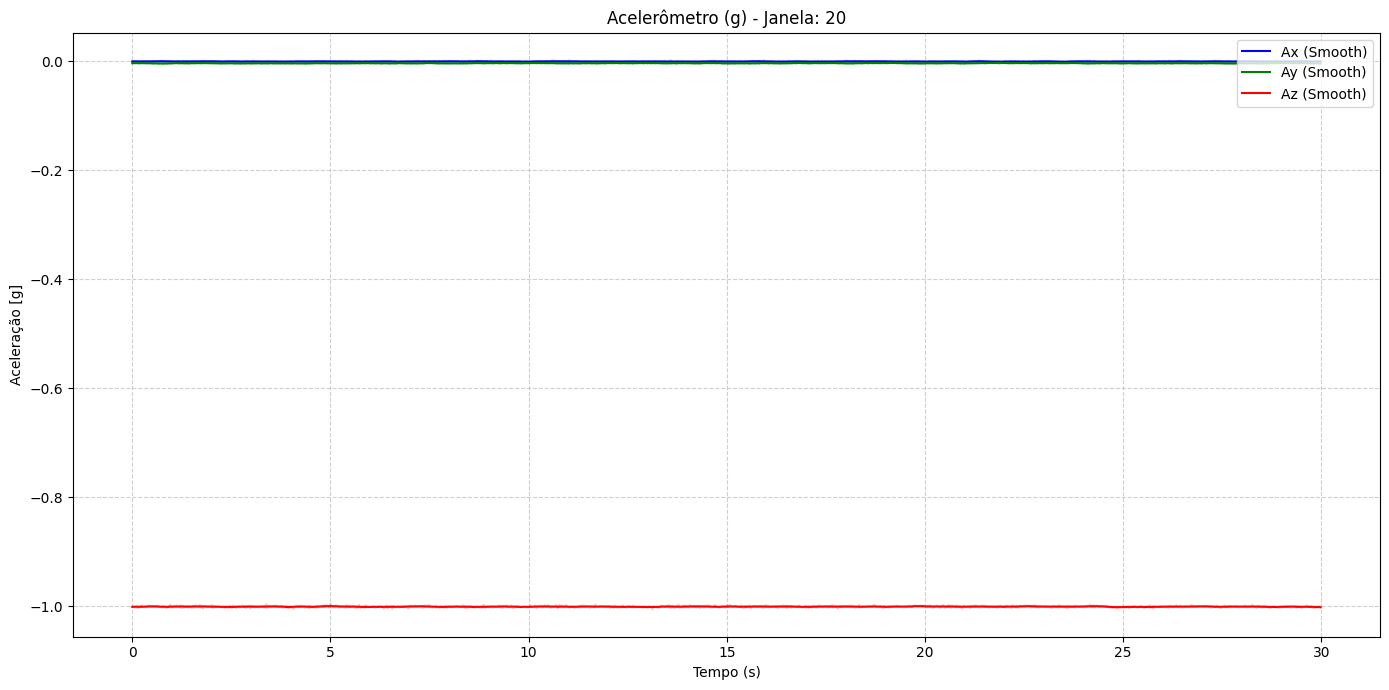

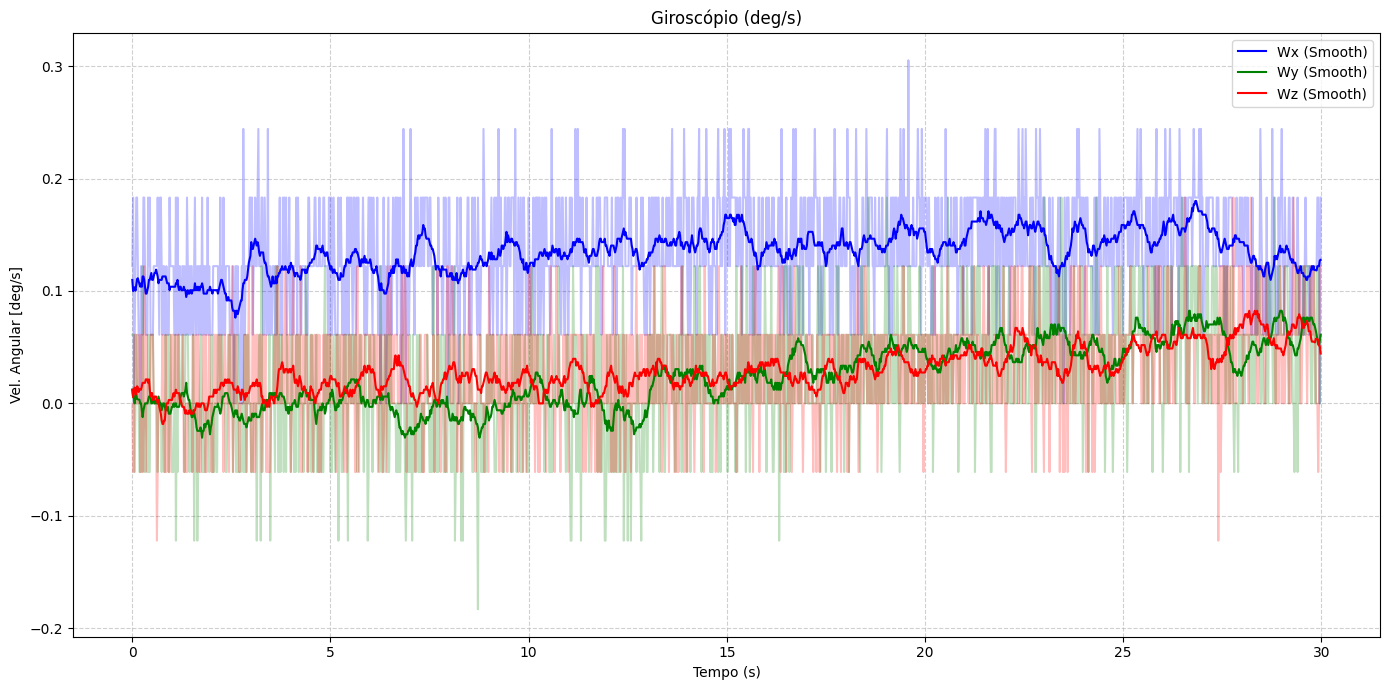

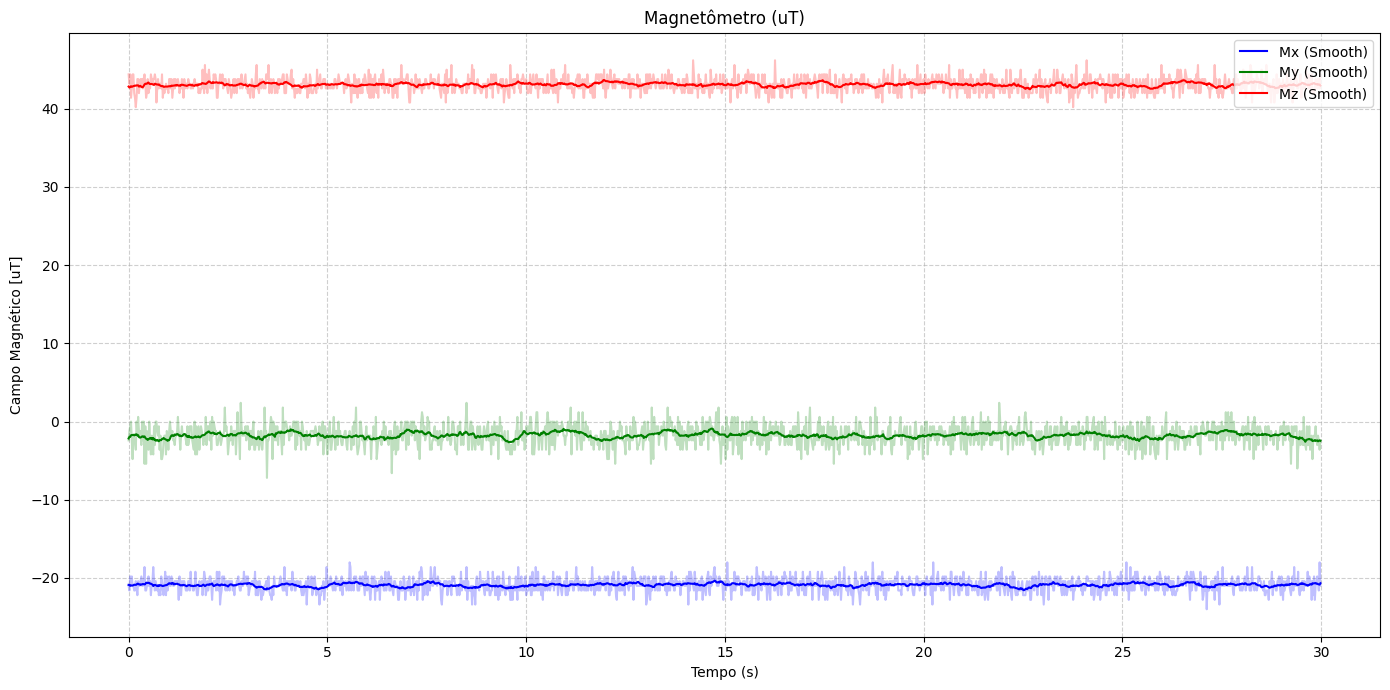

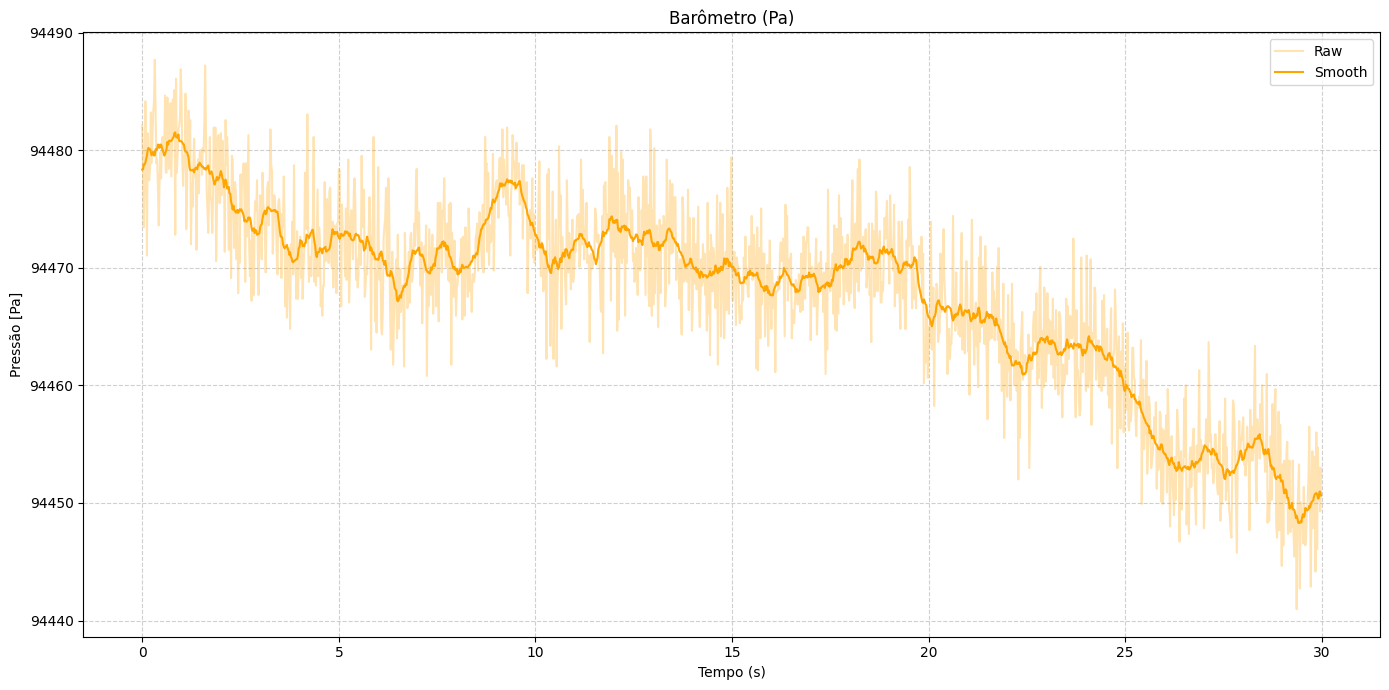

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rocketpy.mathutils import Vector

# ==========================================
# Configuração do Teste (Foguete na Mesa)
# ==========================================

r_sensor = Vector([0, 0, 0]) 

class EnvironmentStub:
    def __init__(self, gravity_val=g0, pressure_val=94475.0):
        class Gravity: 
            def get_value_opt(self, h): return gravity_val
        self.gravity = Gravity()
        self.pressure = lambda h: pressure_val

env_stub = EnvironmentStub()

# ==========================================
# Execução do Teste Estático (9 Eixos + Pressão)
# ==========================================
u_static = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])
u_dot_static = np.zeros(13)

t_final = 30.0
# t_final = 5.0
tempos = np.arange(0, t_final, 1/50.0)
resultados = []

print(f"Simulando {t_final}s de sensores na bancada (50z)...")

for t in tempos:
    # Medições
    mpu9250_accel.measure(t, u=u_static, u_dot=u_dot_static, 
                          relative_position=r_sensor, environment=env_stub)
    
    mpu9250_gyro.measure(t, u=u_static, u_dot=u_dot_static, 
                         relative_position=r_sensor)
    
    mpu9250_mag.measure(t, u=u_static)
    
    bmp280.measure(t, u=u_static, relative_position=r_sensor, environment=env_stub)

    # Armazena os resultados
    resultados.append({
        'time': t,
        # Acelerômetro (m/s²)
        'acc_x_ms2': mpu9250_accel.measurement[0],
        'acc_y_ms2': mpu9250_accel.measurement[1],
        'acc_z_ms2': mpu9250_accel.measurement[2],
        # Giroscópio (rad/s)
        'gyro_x_rads': mpu9250_gyro.measurement[0],
        'gyro_y_rads': mpu9250_gyro.measurement[1],
        'gyro_z_rads': mpu9250_gyro.measurement[2],
        # Magnetômetro (Tesla)
        'mag_x_uT': mpu9250_mag.measurement[0],
        'mag_y_uT': mpu9250_mag.measurement[1],
        'mag_z_uT': mpu9250_mag.measurement[2],
        # Barômetro
        'press_Pa': bmp280.measurement if bmp280.measurement else np.nan
    })

df_sim = pd.DataFrame(resultados).ffill()


def plot_sensor_validation(df, window_size=20):
    """
    Gera gráficos comparativos para todos os sensores, 
    cada um em sua própria figura (janela) separada.
    """

    cols_to_smooth = [
        'acc_x_ms2', 'acc_y_ms2', 'acc_z_ms2',
        'gyro_x_rads', 'gyro_y_rads', 'gyro_z_rads',
        'mag_x_uT', 'mag_y_uT', 'mag_z_uT',
        'press_Pa'
    ]
    
    for col in cols_to_smooth:
        if col in df.columns:
            df[f'{col}_smooth'] = df[col].rolling(window=window_size, center=True, min_periods=1).mean()
    
    # --- Grafico 1: Acelerômetro (g) ---
    plt.figure(figsize=(14, 7))
    g0 = 9.80665
    
    # raw
    plt.plot(df['time'], df['acc_x_ms2']/g0, color='blue', alpha=0.25)
    plt.plot(df['time'], df['acc_y_ms2']/g0, color='green', alpha=0.25)
    plt.plot(df['time'], df['acc_z_ms2']/g0, color='red', alpha=0.25)
    
    # smooth
    plt.plot(df['time'], df['acc_x_ms2_smooth']/g0, color='blue', label='Ax (Smooth)')
    plt.plot(df['time'], df['acc_y_ms2_smooth']/g0, color='green', label='Ay (Smooth)')
    plt.plot(df['time'], df['acc_z_ms2_smooth']/g0, color='red', label='Az (Smooth)')
    
    plt.title(f"Acelerômetro (g) - Janela: {window_size}")
    plt.ylabel("Aceleração [g]")
    plt.xlabel("Tempo (s)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Grafico 2: Giroscópio (deg/s) ---
    plt.figure(figsize=(14, 7))
    rad2deg = 180 / np.pi
    
    # raw
    plt.plot(df['time'], df['gyro_x_rads']*rad2deg, color='blue', alpha=0.25)
    plt.plot(df['time'], df['gyro_y_rads']*rad2deg, color='green', alpha=0.25)
    plt.plot(df['time'], df['gyro_z_rads']*rad2deg, color='red', alpha=0.25)
    
    # smooth
    plt.plot(df['time'], df['gyro_x_rads_smooth']*rad2deg, color='blue', label='Wx (Smooth)')
    plt.plot(df['time'], df['gyro_y_rads_smooth']*rad2deg, color='green', label='Wy (Smooth)')
    plt.plot(df['time'], df['gyro_z_rads_smooth']*rad2deg, color='red', label='Wz (Smooth)')
    
    plt.title("Giroscópio (deg/s)")
    plt.ylabel("Vel. Angular [deg/s]")
    plt.xlabel("Tempo (s)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Grafico 3: Magnetômetro (uT) ---
    plt.figure(figsize=(14, 7))
    t2uT = 1e6
    
    # raw
    plt.plot(df['time'], df['mag_x_uT']*t2uT, color='blue', alpha=0.25)
    plt.plot(df['time'], df['mag_y_uT']*t2uT, color='green', alpha=0.25)
    plt.plot(df['time'], df['mag_z_uT']*t2uT, color='red', alpha=0.25)
    
    # smooth
    plt.plot(df['time'], df['mag_x_uT_smooth']*t2uT, color='blue', label='Mx (Smooth)')
    plt.plot(df['time'], df['mag_y_uT_smooth']*t2uT, color='green', label='My (Smooth)')
    plt.plot(df['time'], df['mag_z_uT_smooth']*t2uT, color='red', label='Mz (Smooth)')
    
    plt.title("Magnetômetro (uT)")
    plt.ylabel("Campo Magnético [uT]")
    plt.xlabel("Tempo (s)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Grafico 4: Barômetro (Pa) ---
    plt.figure(figsize=(14, 7))
    
    # raw
    plt.plot(df['time'], df['press_Pa'], color='orange', alpha=0.3, label='Raw')
    # smooth
    plt.plot(df['time'], df['press_Pa_smooth'], color='orange', label='Smooth')
    
    plt.title("Barômetro (Pa)")
    plt.ylabel("Pressão [Pa]")
    plt.xlabel("Tempo (s)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


print("\n--- Estatísticas Médias da Simulação ---")
print(f"Mag X: {df_sim['mag_x_uT'].mean() * 1e6:.2f} uT ")
print(f"Mag Y: {df_sim['mag_y_uT'].mean() * 1e6:.2f} uT ")
print(f"Mag Z: {df_sim['mag_z_uT'].mean() * 1e6:.2f} uT ")
print(f"Acc Z: {df_sim['acc_z_ms2'].mean() / g0:.4f} g (Esperado em Z-Down: ~-1.0000)")
print(f"Pressão: {df_sim['press_Pa'].mean():.1f} Pa (Esperado: ~94480.8)")


plot_sensor_validation(df_sim, window_size=20)


In [31]:
import csv

# Open the CSV file for reading
filename = "Airbrake_Cd.csv"
with open(filename, mode='r') as file:
    # Create a CSV reader with DictReader
    csv_reader = csv.reader(file)
    header = next(csv_reader)

    # Initialize an empty list to store the dictionaries
    data_list = []

    # Iterate through each row in the CSV file
    for row in csv_reader:
        # Append each row (as a dictionary) to the list
        data_list.append(row)

for i in range(len(data_list)) :
  for j in range(len(data_list[i])):
    data_list[i][j] = float(data_list[i][j])

In [32]:
class PID:
    def __init__(self, Kp, Ki, Kd, setpoint, sample_time, min_output, max_output):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.setpoint = setpoint
        self.sample_time = sample_time
        self.integral = 0
        self.derivative = 0
        self.previous_error = 0
        self.output = 0
        self.integrator_windup = 1
        self.min_output = min_output
        self.max_output = max_output

    def set_integrator_windup(self, integrator_windup):
        self.integrator_windup = integrator_windup

    def set_min_max_output(self, min_output, max_output):
        self.min_output = min_output
        self.max_output = max_output

    def update(self, current_value):
        error = self.setpoint - current_value
        self.integral += error * self.sample_time
        if self.integral > self.integrator_windup:
            self.integral = self.integrator_windup
        elif self.integral < -self.integrator_windup:
            self.integral = -self.integrator_windup
        self.derivative = (error - self.previous_error) / self.sample_time
        self.output = self.Kp * error + self.Ki * self.integral + self.Kd * self.derivative
        if self.output > self.max_output:
            self.output = self.max_output
        elif self.output < self.min_output:
            self.output = self.min_output
        self.previous_error = error
        return self.output

    def set_setpoint(self, new_setpoint):
        self.setpoint = new_setpoint

class KalmanFilter:
    def __init__(self, F, G, H, Q, R, P0, X0, process_noise):
        self.F, self.G, self.H = F, G, H
        self.Q_aux = Q
        self.Q, self.R, self.P0, self.X0 = self.Q_aux*process_noise**2, R, P0, X0
        self.n, self.m, self.r = F.shape[0], G.shape[1], H.shape[0]
        self.estimatesAposteriori, self.covarianceAposteriori = X0, P0
        self.estimatesApriori, self.covarianceApriori = np.zeros((self.n, 1)), np.zeros((self.n, self.n))
        self.KalmanGain, self.residual = np.zeros((self.n, self.r)), np.zeros((self.r, 1))

    def update(self, measurement):
        Sk = np.linalg.inv(self.R + self.H @ self.covarianceApriori @ self.H.T)
        self.KalmanGain = self.covarianceApriori @ self.H.T @ Sk
        self.residual = measurement - self.H @ self.estimatesApriori

        # State Update
        self.estimatesAposteriori = self.estimatesApriori + self.KalmanGain @ self.residual

        I_n = np.eye(self.n)
        KGH = I_n - self.KalmanGain @ self.H

        # Covariance update
        self.covarianceAposteriori = KGH @ self.covarianceApriori @ KGH.T + self.KalmanGain @ self.R @ self.KalmanGain.T

    def predict(self, U):
        # State Extrapolation
        self.estimatesApriori = self.F @ self.estimatesAposteriori + self.G @ U

        # Covariance Extrapolation
        self.covarianceApriori = self.F @ self.covarianceAposteriori @ self.F.T + self.Q

    def get_posteriori_state(self):
        return self.estimatesAposteriori

    def get_posteriori_covariance(self):
        return self.covarianceAposteriori

    def get_priori_state(self):
        return self.estimatesApriori

    def set_process_noise(self, process_noise):
        self.Q = self.Q_aux*process_noise**2

    def get_Mahanalobis_Distance(self):
        return ((self.residual.T @ np.linalg.inv(self.R + self.H @ self.covarianceApriori @ self.H.T) @ self.residual)**0.5)

class ExtendedKalmanFilter:
    def __init__(self, F, G, Q, R, P0, X0, process_noise, elevation):
        self.F, self.G = F, G
        self.Q_aux = Q
        self.Q, self.R, self.P0, self.X0 = Q*process_noise**2, R, P0, X0
        self.n, self.m, self.r = F.shape[0], G.shape[1], H.shape[0]
        self.estimatesAposteriori, self.covarianceAposteriori = X0, P0
        self.estimatesApriori, self.covarianceApriori = np.zeros((self.n, 1)), np.zeros((self.n, self.n))
        self.KalmanGain, self.residual = np.zeros((self.n, self.r)), np.zeros((self.r, 1))
        self.pressure0 = 101325
        self.T0 = 288.16
        self.L = 0.0065
        self.e = (9.80665*0.02896968)/(8.314462618*self.L)
        self.elevation = elevation

    def set_pressure0(self, pressure0):
        self.pressure0 = pressure0

    def h(self, altitude):
        h = self.pressure0*((1 - self.L*(altitude)/self.T0)**(self.e)) ###### ajustar asl/agl
        return np.array([[h]])

    def h_Jacobian(self, altitude):
        H = -(self.e*self.L*self.pressure0*((1 - self.L*(altitude)/self.T0)**(self.e - 1)))/self.T0
        return np.array([[H, 0]])

    def predict(self, U):
        # State Extrapolation
        self.estimatesApriori = self.F @ self.estimatesAposteriori + self.G @ U

        # Covariance Extrapolation
        self.covarianceApriori = self.F @ self.covarianceAposteriori @ self.F.T + self.Q

    def update(self, measurement):
        H = self.h_Jacobian(self.estimatesApriori.flatten()[0])
        Sk = np.linalg.inv(self.R + H @ self.covarianceApriori @ H.T)
        self.KalmanGain = self.covarianceApriori @ H.T @ Sk
        self.residual = measurement - self.h(self.estimatesApriori.flatten()[0])

        # State Update
        self.estimatesAposteriori = self.estimatesApriori + self.KalmanGain @ self.residual

        I_n = np.eye(self.n)
        KGH = I_n - self.KalmanGain @ H

        # Covariance update
        self.covarianceAposteriori = KGH @ self.covarianceApriori @ KGH.T + self.KalmanGain @ self.R @ self.KalmanGain.T

    def get_posteriori_state(self):
        return self.estimatesAposteriori

    def get_posteriori_covariance(self):
        return self.covarianceAposteriori

    def get_priori_state(self):
        return self.estimatesApriori

    def set_process_noise(self, process_noise):
        self.Q = self.Q_aux*process_noise**2

    def get_Mahanalobis_Distance(self):
        return ((self.residual.T @ np.linalg.inv(self.R + H @ self.covarianceApriori @ H.T) @ self.residual)**0.5)

class RungeKutta4:
    def __init__(self, n, dt):
        self.n = n
        self.dt = dt
        self.PredictedApogee = 0
        self.u_dot = np.zeros(n)
        self.u1 = np.zeros(n)
        self.u2 = np.zeros(n)
        self.u3 = np.zeros(n)
        self.u = np.zeros(n)
        self.z = []
        self.vz = []
        self.dt_over_2 = self.dt / 2.0

    def ODE(self, t, u, input):
        self.u_dot[0] = u[1]
        self.u_dot[1] = input # TODO: Corrigir aceleração
        return self.u_dot

    def ComputeRK4(self, u0, input):
        f0 = self.ODE(self.t0, u0, input)
        f1 = self.ODE(self.t0 + self.dt_over_2, u0, input)
        f2 = self.ODE(self.t0 + self.dt_over_2, u0, input)
        f3 = self.ODE(self.t0 + self.dt, u0, input)

        for i in range(self.n):
            self.u[i] = u0[i] + self.dt * (f0[i] + 2.0 * f1[i] + 2.0 * f2[i] + f3[i]) / 6.0

        return self.u

    def predict_apogee(self, t0, stop_time, u0, input):
        max_z = u0[0]  # Initialize max_z to the first element
        self.t0 = t0

        while u0[1] >= -1e-3: # TODO: Arrumar essa porra
            z_value = u0[0]

            # Update max_z if necessary
            if z_value > max_z:
                max_z = z_value

            self.vz.append(u0[1])
            t0 += self.dt
            u0 = self.ComputeRK4(u0, input)

        self.PredictedApogee = max_z
        self.z.append(max_z)
        print("Apogeu = ", self.PredictedApogee)
        return self.PredictedApogee

class FeedforwardController:
    def __init__(self, m, S):
        self.m = m  # mass of the rocket
        self.S = S  # reference area of the rocket

    def compute_drag_coefficient(self, desired_apogee, current_altitude, current_velocity, gravity, rho):
        if (2*(desired_apogee - current_altitude)) < 1:
          divisor1 = 1
        else:
          divisor1 = (2*(desired_apogee - current_altitude))
        acc_desejado = - current_velocity**2 / divisor1
        if (self.S*rho*(current_velocity**2)) < 1:
          divisor2 = 1
        else:
          divisor2 = (self.S*rho*(current_velocity**2))
        Cd_desired = - 2*self.m*(acc_desejado - gravity)/divisor2
        if (Cd_desired < 0 or acc_desejado > 0):
          Cd_desired = 0
        return np.clip(Cd_desired, 0, 1), acc_desejado

class MovingAverage:
    def __init__(self, window_size):
        self.window_size = window_size
        self.data = []
        self.average_past = 0
        self.decrease_counter = 0
        self.increase_counter = 0

    def update(self, value):
        self.data.append(value)
        if len(self.data) > self.window_size:
            self.data.pop(0)
        if len(self.data) == 0:
            return 0
        average = sum(self.data) / self.window_size
        if average < self.average_past:
          self.average_past = average
          self.decrease_counter += 1
          if self.decrease_counter == 10:
            self.decrease_counter = 0
            return "decreasing"
        elif average > self.average_past:
          self.average_past = average
          self.increase_counter += 1
          if self.increase_counter == 10:
            self.increase_counter = 0
            return "increasing"
        self.average_past = average
        return 0

class FiniteStateMachine:
    def __init__(self):
        self.state = "idle"
        self.apogee = 0

    def update(self, movingAverage_Signal, x):
        if self.state == "idle":
            if movingAverage_Signal == "increasing":
                self.state = "motor_on"

        elif self.state == "motor_on":
            if movingAverage_Signal == "decreasing":
                self.state = "motor_off"

        elif self.state == "motor_off":
            if x[1] < -0.1:
                self.apogee_reached = True
                self.apogee = x[0]
                self.state = "apogee_reached"

    def get_state(self):
        return self.state

    def get_apogee(self):
        return self.apogee

In [33]:
import pandas as pd

# Supondo que data_list contenha os dados do arquivo CSV
df = pd.DataFrame(data_list, columns=["deployment_level", "mach", "cd"])

def find_nearest_deployment(cd, mach):
  if cd < 0:
    return 0
  df["distance"] = (df["cd"] - cd)**2 + (df["mach"] - mach)**2
  nearest_index = df["distance"].idxmin()
  nearest_deployment = df["deployment_level"][nearest_index]
  return nearest_deployment

# Exemplo de uso
cd = 0.6
mach = 0.4
nearest_deployment = find_nearest_deployment(cd, mach)
print(f"O deployment level mais próximo para cd={cd} e mach={mach} é {nearest_deployment}")

data = pd.read_csv('Curva_3km_Hibrido_AltitudexVz.csv')

altitude_vector = data.iloc[:, 1]
vz_vector = data.iloc[:, 2]

def find_nearest_velocity(input_altitude):
    # Find the index of the altitude closest to the input altitude
    index = np.abs(altitude_vector - input_altitude).argmin()
    # Return the velocity at that index
    return vz_vector[index]

O deployment level mais próximo para cd=0.6 e mach=0.4 é 0.4


In [34]:
sampling_rate = 50 # Hz
dt_k = 1/sampling_rate
noise_std = 5
process_noise = 1

F = np.array([[1, dt_k], [0, 1]])
G = np.array([[0.5 * dt_k ** 2], [dt_k]])
H = np.array([[1, 0]])
P0 = 1e-6 * np.eye(2)
R = np.array([[noise_std ** 2]])
Q = np.array([[dt_k ** 4 / 4, dt_k ** 3 / 2],
              [dt_k ** 3 / 2, dt_k ** 2    ]])
x0 = np.array([[0], [0]])
KF = KalmanFilter(F, G, H, Q, R, P0, x0, process_noise=process_noise)

g = lambda h: -9.80665*(6371.009*10**3/(6371.009*10**3 + h))**2
mass = pacifico_Controlled.dry_mass
S =  np.pi * pacifico.radius**2
FeedForward = FeedforwardController(mass, S)

Kp = 0.025
Ki = 0.075
Kd = 0.02
setpoint = 0 # TODO: Projetar a malha de controle
PID_Controller = PID(Kp, Ki, Kd, setpoint, sampling_rate, min_output = 0, max_output = 1)
desired_apogee = 3000

MovingAverage_Object = MovingAverage(window_size = 50)
FSM = FiniteStateMachine()

def controller_function(
    time, sampling_rate, state, state_history, observed_variables, air_brakes
):
    # state = [x, y, z, vx, vy, vz, e0, e1, e2, e3, wx, wy, wz]
    elevation = env.elevation
    altitude_ASL = state[2]
    altitude_AGL = altitude_ASL - elevation
    vx, vy, vz = state[3], state[4], state[5]

    speed_of_sound_real = env.speed_of_sound(altitude_ASL)
    temperature_real = env.temperature(altitude_ASL)

    # Get winds in x and y directions
    wind_x, wind_y = env.wind_velocity_x(altitude_ASL), env.wind_velocity_y(altitude_ASL)
    # Calculate Mach number
    free_stream_speed = (
        (wind_x - vx) ** 2 + (wind_y - vy) ** 2 + (vz) ** 2
    ) ** 0.5
    mach_number_real = free_stream_speed / speed_of_sound_real

    x = KF.get_posteriori_state().flatten()
    gravity = g(x[0])
    temperature = 298.15 - 0.0065*(x[0] + elevation)
    pressure = 101325*(1 - 0.0065*(x[0] + elevation)/288.15)**(9.80665*0.02896968/(8.31447*0.0065))
    rho = pressure*0.0289644/(8.31447*temperature)         #rho = 1.293
    #speed_of_sound = (1.4*pressure/rho)**0.5
    speed_of_sound = 331.3*(1+(temperature-273.15)/273.15)**0.5
    mach_number = x[1] / speed_of_sound
    Cd = air_brakes.drag_coefficient(air_brakes.deployment_level, mach_number)
    drag_acceleration = -0.5*Cd*S*rho*(x[1]**2)/mass
    z_measured = altitude_AGL + np.random.normal(0,noise_std) # TODO: ver desvio do barômetro
    #z_measured = env.pressure(altitude_ASL) + np.random.normal(0,noise_std)
    FSM.update(MovingAverage_Object.update(x[1]), x)
    if FSM.get_state() == "idle":
      state_history = 0
      inputU = np.array([[0]])
    elif FSM.get_state() == "motor_on":
      state_history = 1
      inputU = np.array([[0.01]])
    elif FSM.get_state() == "motor_off":
      state_history = 2
      inputU = np.array([[gravity]])
    elif FSM.get_state() == "apogee_reached":
      state_history = 3
      inputU = np.array([[gravity]])
    KF.predict(inputU)
    outputY = np.array([[z_measured]])
    KF.update(outputY)
    x = KF.get_posteriori_state().flatten()
    covarianceMatrix = KF.get_posteriori_covariance()
    mahanalobis_distance = KF.get_Mahanalobis_Distance()[0][0]
    predicted_Apogee = 0
    v_ideal = find_nearest_velocity(x[0])
    delta_v = v_ideal - x[1]
    if v_ideal > x[1]:
      delta_v = 0
    Cd_desired, acc_desejado = FeedForward.compute_drag_coefficient(desired_apogee, x[0], x[1], gravity, rho)
    # If below 1500 meters above ground level, air_brakes are not deployed
    if x[1] > 0.7*speed_of_sound or FSM.get_state() == "motor_on" or FSM.get_state() == "apogee_reached":
        air_brakes.deployment_level = 0
        PID_Output = 0
        exact_deployment = 0
        Cd_desired = 0
        acc_desejado = 0
    # Else calculate the deployment level
    else:
        PID_Output = PID_Controller.update(delta_v)
        Cd_desired = Cd_desired + PID_Output
        new_deployment_level = find_nearest_deployment(Cd_desired, mach_number)
        exact_deployment = new_deployment_level
        if Cd_desired == 0:
          new_deployment_level = 0
        if x[0] > 3000:
          new_deployment_level = 1
        # Limiting the speed of the air_brakes to n per second
        # Since this function is called every 1/sampling_rate seconds
        # the max change in deployment level per call is n/sampling_rate
        max_change = 0.5 / sampling_rate
        lower_bound = air_brakes.deployment_level - max_change
        upper_bound = air_brakes.deployment_level + max_change
        new_deployment_level = min(max(new_deployment_level, lower_bound), upper_bound)

        air_brakes.deployment_level = max(0, min(new_deployment_level, 1))  # Clamp between 0 and 1

    if x[0] > desired_apogee:
      air_brakes.deployment_level = 1
    if x[1] < -1:
      air_brakes.deployment_level = 0

    # Return variables of interest to be saved in the observed_variables list
    return (
        time,
        air_brakes.deployment_level,
        exact_deployment,
        air_brakes.drag_coefficient(air_brakes.deployment_level, mach_number_real),
        x,
        predicted_Apogee,
        delta_v,
        PID_Output,
        acc_desejado,
        Cd_desired,
        temperature,
        temperature_real,
        speed_of_sound,
        speed_of_sound_real,
        mahanalobis_distance,
        gravity,
        rho,
        pressure,
        z_measured,
        state_history,
    )

In [35]:
air_brakes = pacifico_Controlled.add_air_brakes(
    drag_coefficient_curve="Airbrake_Cd.csv",
    #drag_coefficient_curve="/content/air_brakes_cd.csv",
    controller_function=controller_function,
    sampling_rate=sampling_rate,
    reference_area=np.pi * pacifico.radius**2,
    clamp=True,
    initial_observed_variables=[0, 0, 0, 0, [x0.flatten()[0], x0.flatten()[1]], 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    override_rocket_drag=True,
    name="Air Brakes",
)

In [36]:
test_flight = Flight(
    rocket=pacifico, environment=env, rail_length=5.4, inclination=86, heading=156,
    time_overshoot=False,
    terminate_on_apogee=True,
)

test_flight_Controlled = Flight(
    rocket=pacifico_Controlled, environment=env, rail_length=5.4, inclination=86, heading=156,
    time_overshoot=False,
    terminate_on_apogee=True,
)

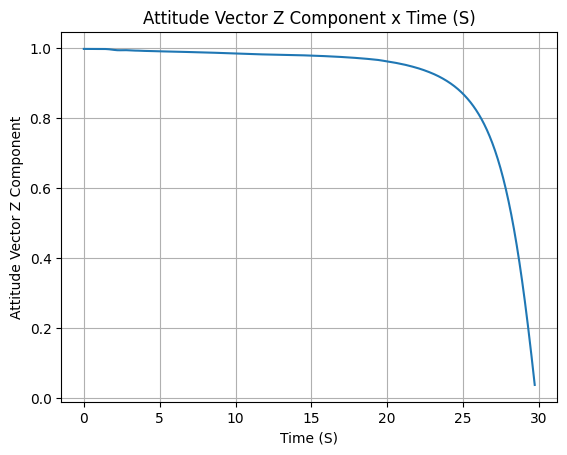

In [37]:
# test_flight_Controlled.altitude()
a = test_flight.attitude_vector_z()

In [38]:
from rocketpy.simulation.flight_data_exporter import FlightDataExporter

exporter = FlightDataExporter(test_flight)
exporter.export_data("Teste_HIL.csv", "pressure","az","attitude_angle",time_step=0.02)

In [39]:
exporter.export_sensor_data("Sensor_raw.csv")

Sensor data exported to:  Sensor_raw.csv


In [40]:
import json
import pandas as pd
import numpy as np
import os

def organizar_arquivo_sensores(caminho_entrada, dt=None, caminho_saida="Teste_HIL_Sensors.csv"):
    print(f"Lendo arquivo: {caminho_entrada}...")
    
    try:
        with open(caminho_entrada, 'r') as f:
            conteudo = f.read()
            dados_raw = json.loads(conteudo)
    except Exception as e:
        return f"Erro ao ler JSON: {e}"

    dfs = []
    for nome_sensor, dados_lista in dados_raw.items():
        if "BMP" in nome_sensor or "Baro" in nome_sensor:
            cols = ['time', 'pressure_Pa']
        elif "Accel" in nome_sensor:
            cols = ['time', 'accel_x_ms2', 'accel_y_ms2', 'accel_z_ms2']
        elif "Gyro" in nome_sensor:
            cols = ['time', 'gyro_x_rads', 'gyro_y_rads', 'gyro_z_rads']
        elif "Mag" in nome_sensor:
            cols = ['time', 'mag_x_T', 'mag_y_T', 'mag_z_T']
        else:
            cols = ['time'] + [f"val_{i}" for i in range(len(dados_lista[0])-1)]

        df = pd.DataFrame(dados_lista, columns=cols)
        df['time'] = df['time'].round(6)
        df.set_index('time', inplace=True)
        df = df[~df.index.duplicated(keep='first')]
        dfs.append(df)

    if not dfs: return "Nenhum dado encontrado."

    df_final = dfs[0]
    for df in dfs[1:]:
        df_final = df_final.join(df, how='outer')

    df_final.sort_index(inplace=True)

    if dt is not None:
        print(f"Reamostrando dados para dt = {dt}s...")
        t_start, t_end = df_final.index.min(), df_final.index.max()
        novo_index = np.round(np.arange(t_start, t_end + dt/1000.0, dt), 6)
        uniao_index = df_final.index.union(novo_index).unique().sort_values()
        df_final = df_final.reindex(uniao_index)
        df_final.interpolate(method='index', inplace=True)
        df_final.bfill(inplace=True)
        df_final.ffill(inplace=True)
        df_final = df_final.reindex(novo_index)
    else:
        df_final.interpolate(method='index', inplace=True)
        df_final.bfill(inplace=True)
        df_final.ffill(inplace=True)

    df_final.index.name = 'time'
    df_final.reset_index(inplace=True) # Garante que 'time' seja coluna
    import os
    if not os.path.exists("HIL_SIM"): os.makedirs("HIL_SIM")
    nome_base = os.path.basename(caminho_saida).replace(".csv", "")
    caminho_zup = os.path.join("HIL_SIM", f"{nome_base}_ZUp.csv")
    df_final.to_csv(caminho_zup, index=False, float_format="%.6f")
    df_zdown = df_final.copy()
    for col in df_zdown.columns:
        if any(s in col.lower() for s in ["accel_x", "accel_z", "gyro_x", "gyro_z", "mag_x", "mag_z"]):
            df_zdown[col] = -df_zdown[col]
    caminho_zdown = os.path.join("HIL_SIM", f"{nome_base}_ZDown.csv")
    df_zdown.to_csv(caminho_zdown, index=False, float_format="%.6f")
    print(f"Salvo: {caminho_zup} e {caminho_zdown}")
    return df_final


df_limpo = organizar_arquivo_sensores("Sensor_raw.csv", dt=0.02, caminho_saida="Teste_HIL_Sensors.csv")


Lendo arquivo: Sensor_raw.csv...
Reamostrando dados para dt = 0.02s...
Salvo: HIL_SIM\Teste_HIL_Sensors_ZUp.csv e HIL_SIM\Teste_HIL_Sensors_ZDown.csv


In [41]:
def gerar_csv_completo(flight_obj, df_sensores, nome_arquivo="Teste_HIL_Completo.csv"):
    print("Iniciando fusão de dados (Sensor + sim). RAW Mode...")
    times = df_sensores['time'].values if 'time' in df_sensores.columns else df_sensores.index.values
    B_inertial = magnetic_field_sp

    # --- Dinâmica Ground Truth ---
    df_sensores['sim_z'] = flight_obj.altitude(times)
    df_sensores['sim_vz'] = flight_obj.vz(times)
    df_sensores['sim_az'] = flight_obj.az(times)
    
    ax_body = flight_obj.ax_body_frame(times)
    ay_body = flight_obj.ay_body_frame(times)
    az_body = flight_obj.az_body_frame(times)
    
    e0, e1, e2, e3 = flight_obj.e0(times), flight_obj.e1(times), flight_obj.e2(times), flight_obj.e3(times)
    
    g_values = np.array([flight_obj.env.gravity.get_value_opt(z) for z in flight_obj.z(times)])
    g_inertial_arr = np.array([[0, 0, -g] for g in g_values]) 
    
    gravity_body_list, mag_body_list = [], []
    for k in range(len(times)):
        q0, q1, q2, q3 = e0[k], e1[k], e2[k], e3[k]
        r00, r01, r02 = 1 - 2*(q2**2 + q3**2), 2*(q1*q2 - q0*q3), 2*(q1*q3 + q0*q2)
        r10, r11, r12 = 2*(q1*q2 + q0*q3), 1 - 2*(q1**2 + q3**2), 2*(q2*q3 - q0*q1)
        r20, r21, r22 = 2*(q1*q3 - q0*q2), 2*(q2*q3 + q0*q1), 1 - 2*(q1**2 + q2**2)
        dcm_ib = np.array([[r00, r10, r20], [r01, r11, r21], [r02, r12, r22]])
        gravity_body_list.append(dcm_ib @ g_inertial_arr[k])
        mag_body_list.append(dcm_ib @ B_inertial)
    
    gravity_body, mag_body = np.array(gravity_body_list), np.array(mag_body_list)

    # Cálculos de Simulação (Ground Truth)
    df_sensores['sim_ax_loc_ms2'] = ax_body - gravity_body[:, 0]
    df_sensores['sim_ay_loc_ms2'] = ay_body - gravity_body[:, 1]
    df_sensores['sim_az_loc_ms2'] = az_body - gravity_body[:, 2]
    df_sensores['sim_mx_T'] = mag_body[:, 0]
    df_sensores['sim_my_T'] = -mag_body[:, 1]
    df_sensores['sim_mz_T'] = -mag_body[:, 2]
    df_sensores['sim_gx_rads'] = flight_obj.w1(times)
    df_sensores['sim_gy_rads'] = flight_obj.w2(times)
    df_sensores['sim_gz_rads'] = flight_obj.w3(times)
    df_sensores['sim_q0'], df_sensores['sim_q1'], df_sensores['sim_q2'], df_sensores['sim_q3'] = e0, e1, e2, e3
    df_sensores['sim_tilt'] = 90 - (1 - 2 * (e1**2 + e2**2))*90
    
    try:
        df_sensores['sim_pressure_Pa'] = flight_obj.pressure(times)
    except:
        df_sensores['sim_pressure_Pa'] = [flight_obj.env.pressure(z) for z in df_sensores['sim_z']]

    # Gerar DF Final com a mesma convenção para os sensores "ideais"
    df_zup = df_sensores.copy()
    
    # Sobrescrever dados de sensor com os valores ideais 
#     df_zup['accel_x_ms2'] = df_sensores['sim_ax_loc_ms2']
#     df_zup['accel_y_ms2'] = df_sensores['sim_ay_loc_ms2']
#     df_zup['accel_z_ms2'] = df_sensores['sim_az_loc_ms2'] 
    
#     df_zup['gyro_x_rads'] = df_sensores['sim_gx_rads']
#     df_zup['gyro_y_rads'] = df_sensores['sim_gy_rads']
#     df_zup['gyro_z_rads'] = df_sensores['sim_gz_rads']
    
#     df_zup['mag_x_T'] = df_sensores['sim_mx_T']
#     df_zup['mag_y_T'] = df_sensores['sim_my_T']
#     df_zup['mag_z_T'] = df_sensores['sim_mz_T']
    
#     df_zup['pressure_Pa'] = df_sensores['sim_pressure_Pa']

    # Reordenar colunas para manter as sim_ no final
    cols = df_zup.columns.tolist()
    cols_sim = [c for c in cols if 'sim' in c]
    cols_sensors = [c for c in cols if 'sim' not in c]
    df_zup = df_zup[cols_sensors + cols_sim]

    # Salvar arquivos
    import os
    if not os.path.exists("HIL_SIM"): os.makedirs("HIL_SIM")
    
    nome_base = nome_arquivo.replace(".csv", "")
    df_zup.to_csv(os.path.join("HIL_SIM", f"{nome_base}_ZUp.csv"), index=False, float_format='%.8f')
    
    # Versão Z-Down
    df_zdown = df_zup.copy()
    for col in df_zdown.columns:
        if any(sub in col.lower() for sub in ['accel_x', 'accel_z', 'gyro_x', 'gyro_z', 'mag_x', 'mag_z']):
            df_zdown[col] = -df_zdown[col]
    df_zdown.to_csv(os.path.join("HIL_SIM", f"{nome_base}_ZDown.csv"), index=False, float_format='%.8f')
    # Salvar versao apenas com sensores (sem as colunas sim_)
    df_sensors_only_zup = df_zup[cols_sensors]
    df_sensors_only_zup.to_csv(os.path.join("HIL_SIM", "Teste_HIL_Sensors_ZUp.csv"), index=False, float_format="%.8f")
    df_sensors_only_zdown = df_zdown[cols_sensors]
    df_sensors_only_zdown.to_csv(os.path.join("HIL_SIM", "Teste_HIL_Sensors_ZDown.csv"), index=False, float_format="%.8f")

    print(f"Arquivos HIL gerados. Az(Sim) e Az(Sensor) agora possuem o mesmo sinal.")
    return df_zup


df_final = gerar_csv_completo(test_flight, df_limpo, "Teste_HIL_Completo.csv")

Iniciando fusão de dados (Sensor + sim). RAW Mode...
Arquivos HIL gerados. Az(Sim) e Az(Sensor) agora possuem o mesmo sinal.


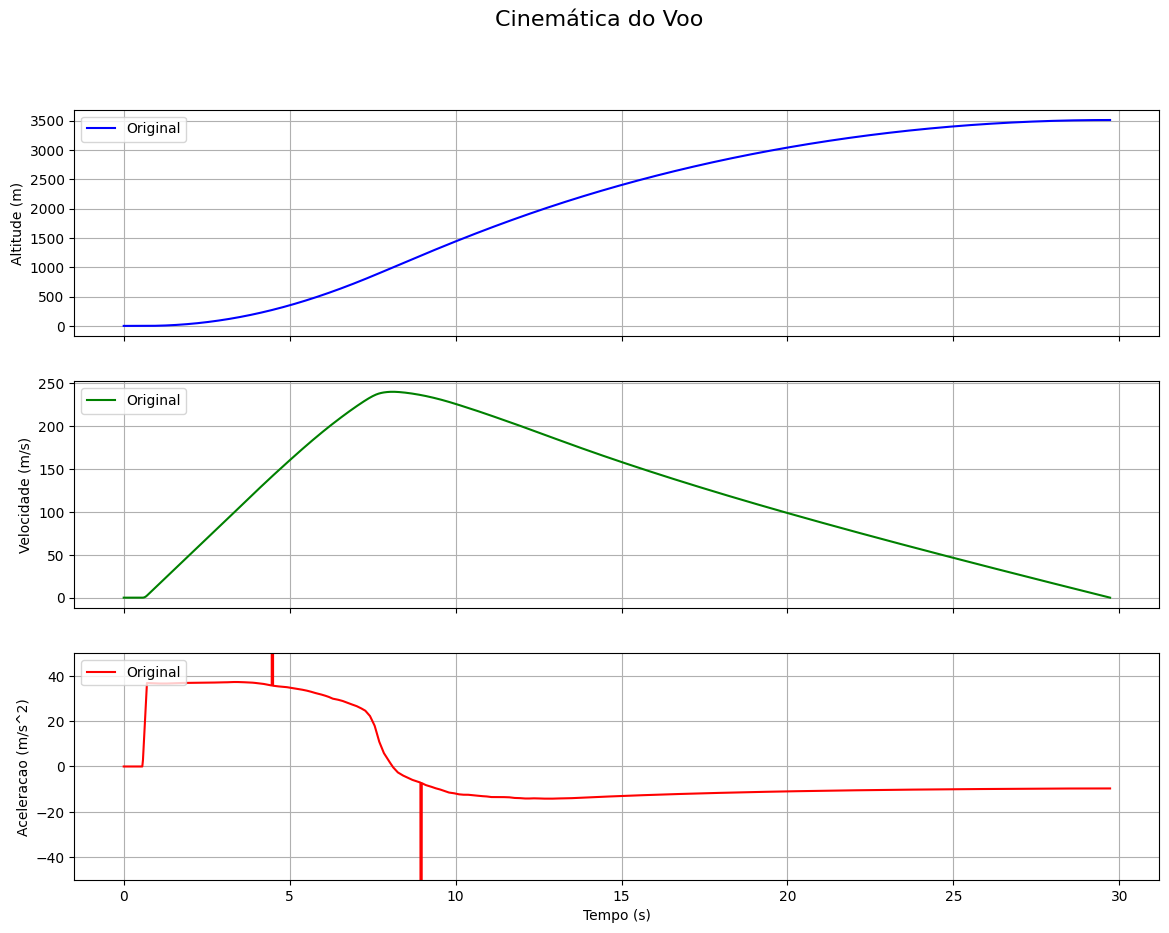

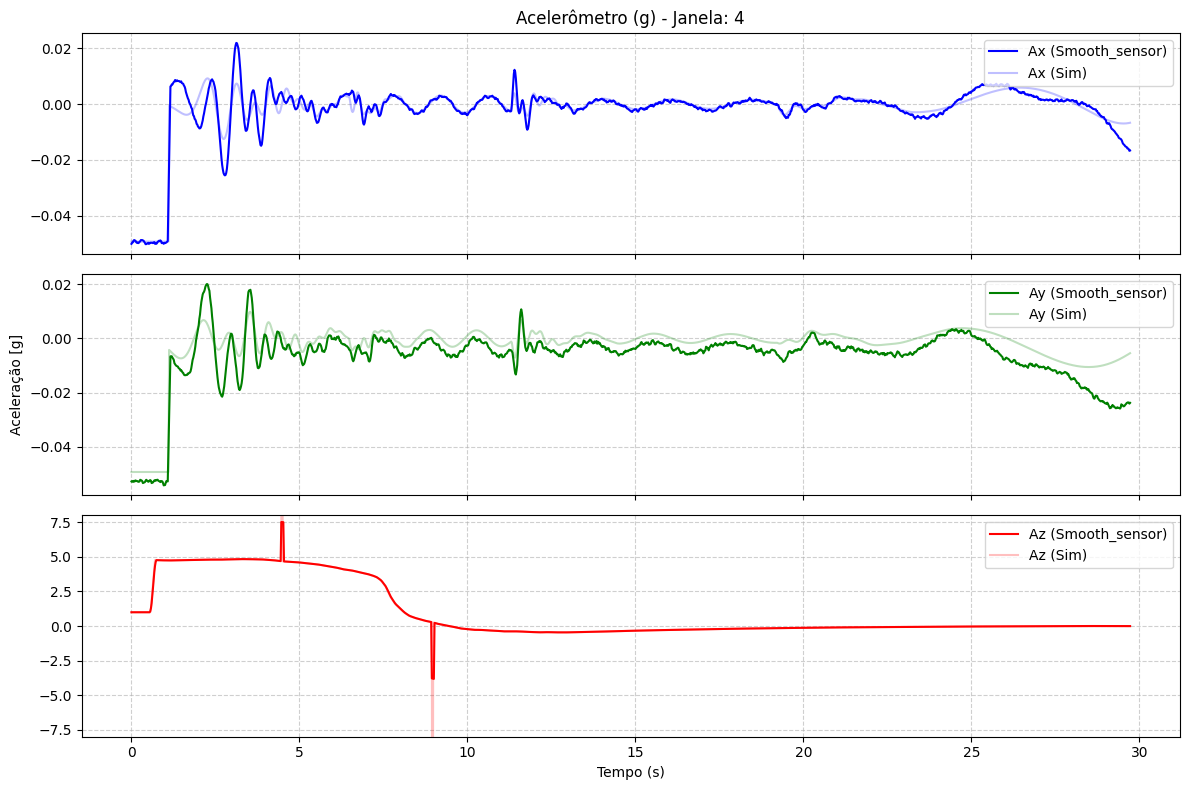

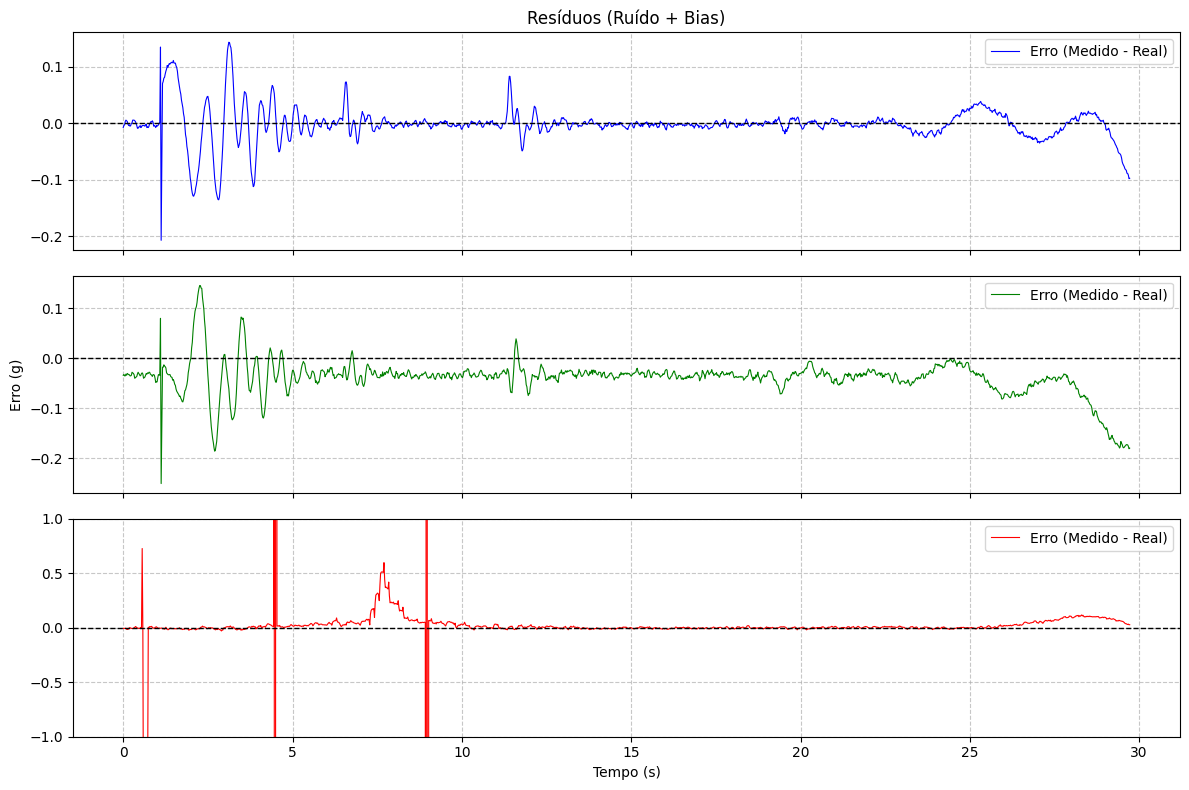

--- Estatísticas de Erro do Acelerometro ---
Bias Médio (Erro Sistemático): Ax=-0.0018 g, Ay=-0.0396 g, Az=-0.1900 g
Desvio Padrão (Ruído Percebido): Ax=0.0304 g, Ay=0.0368 g, Az=18.6467 g
RMSE (Erro Quadrático Médio): Ax=0.0305 g, Ay=0.0541 g, Az=18.6476 g


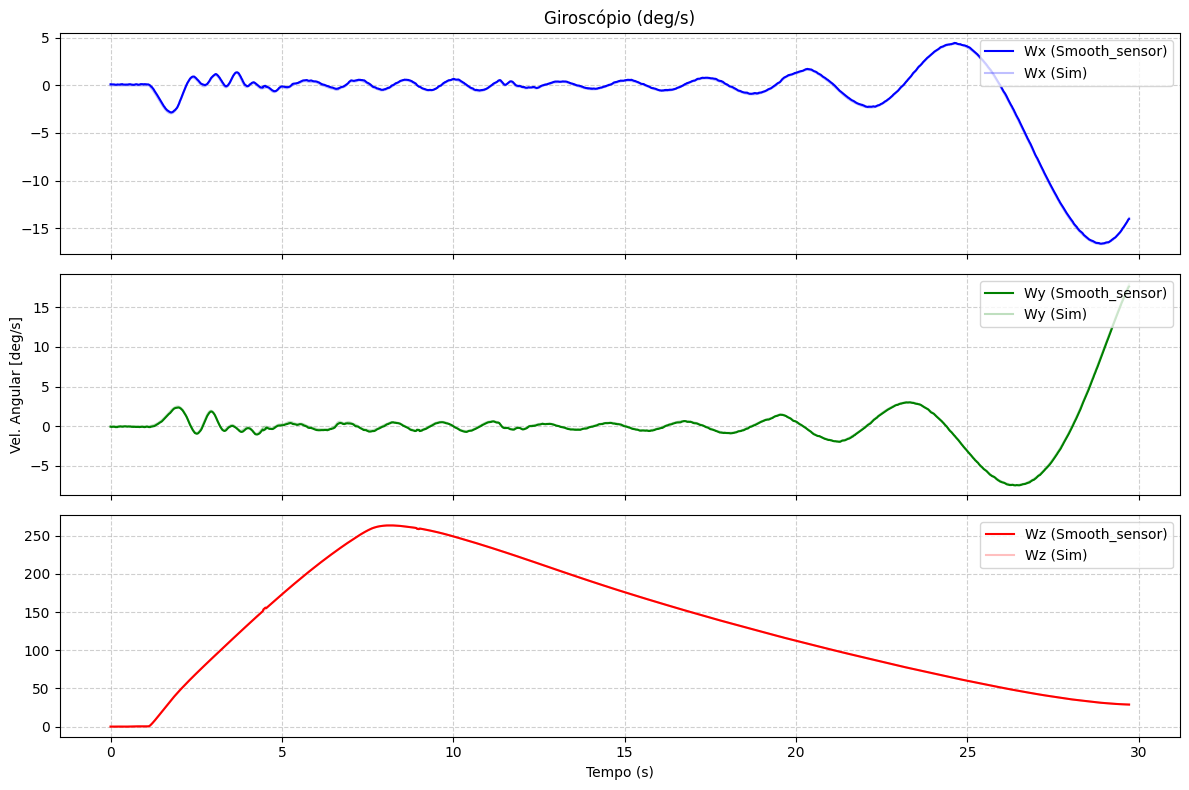

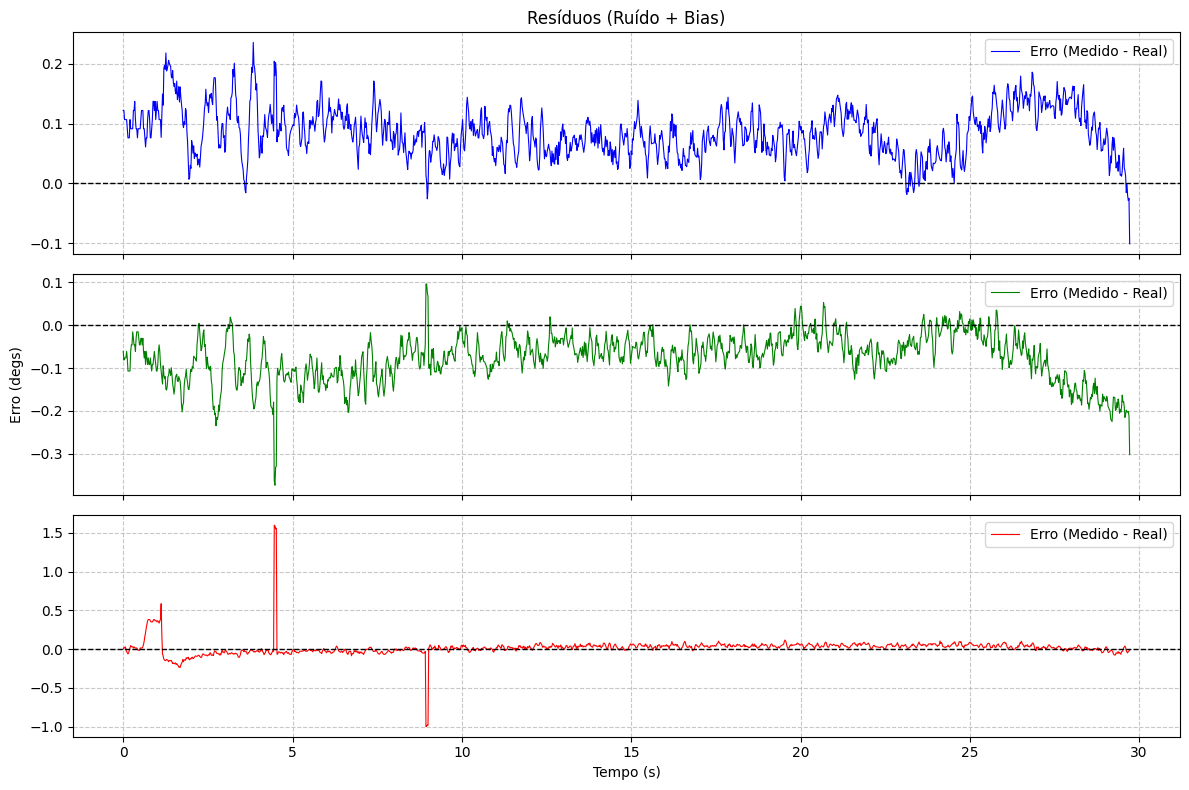

--- Estatísticas de Erro do Giroscopio ---
Bias Médio (Erro Sistemático): gx=0.0851 deg/s, gy=-0.0757 deg/s, gz=0.0180 deg/s
Desvio Padrão (Ruído Percebido): gx=0.0406 deg/s, gy=0.0543 deg/s, gz=0.1173 deg/s
RMSE (Erro Quadrático Médio): gx=0.0943 deg/s, gy=0.0931 deg/s, gz=0.1187 deg/s


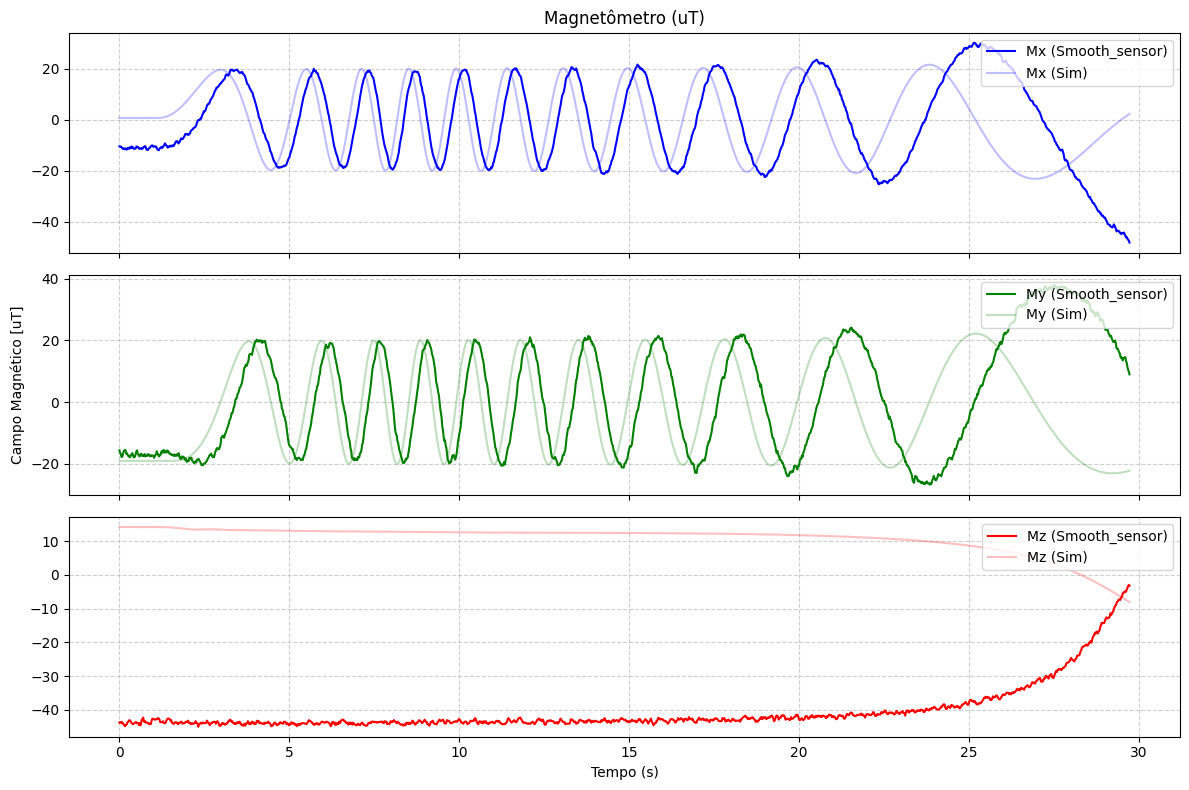

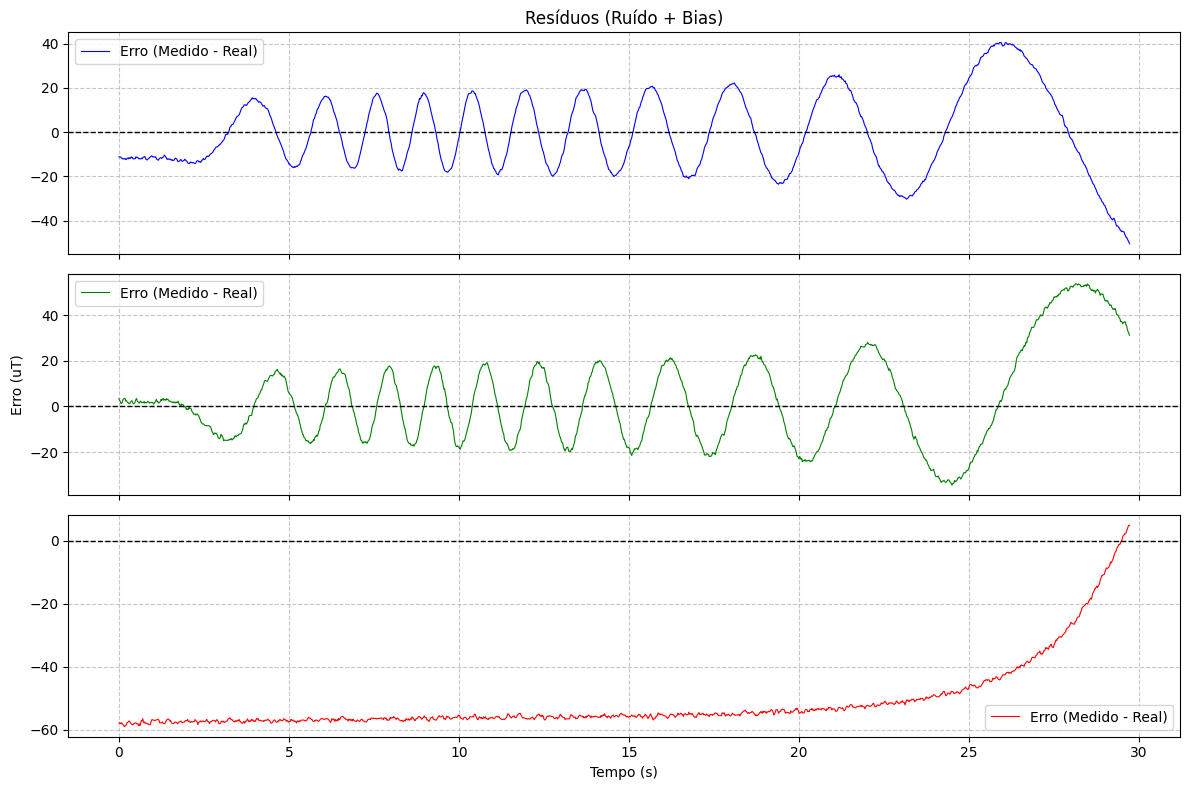

--- Estatísticas de Erro do Magnetometro ---
Bias Médio (Erro Sistemático): mx=-0.3704 uT, my=3.5038 uT, mz=-51.1197 uT
Desvio Padrão (Ruído Percebido): mx=18.0611 uT, my=20.1325 uT, mz=11.4636 uT
RMSE (Erro Quadrático Médio): mx=18.0649 uT, my=20.4352 uT, mz=52.3893 uT


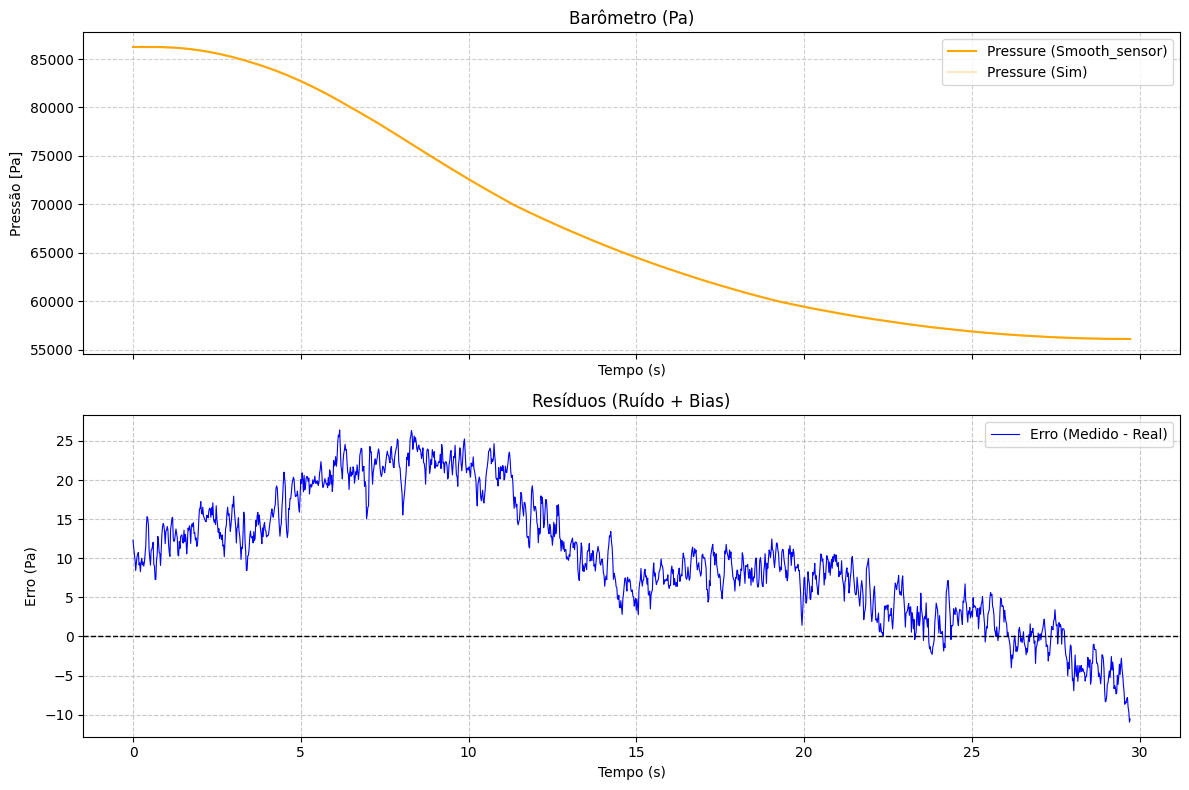

--- Estatísticas de Erro do Barômetro ---
Bias Médio (Erro Sistemático): 10.2638 Pa
Desvio Padrão (Ruído Percebido): 8.0811 Pa
RMSE (Erro Quadrático Médio): 13.0633 Pa


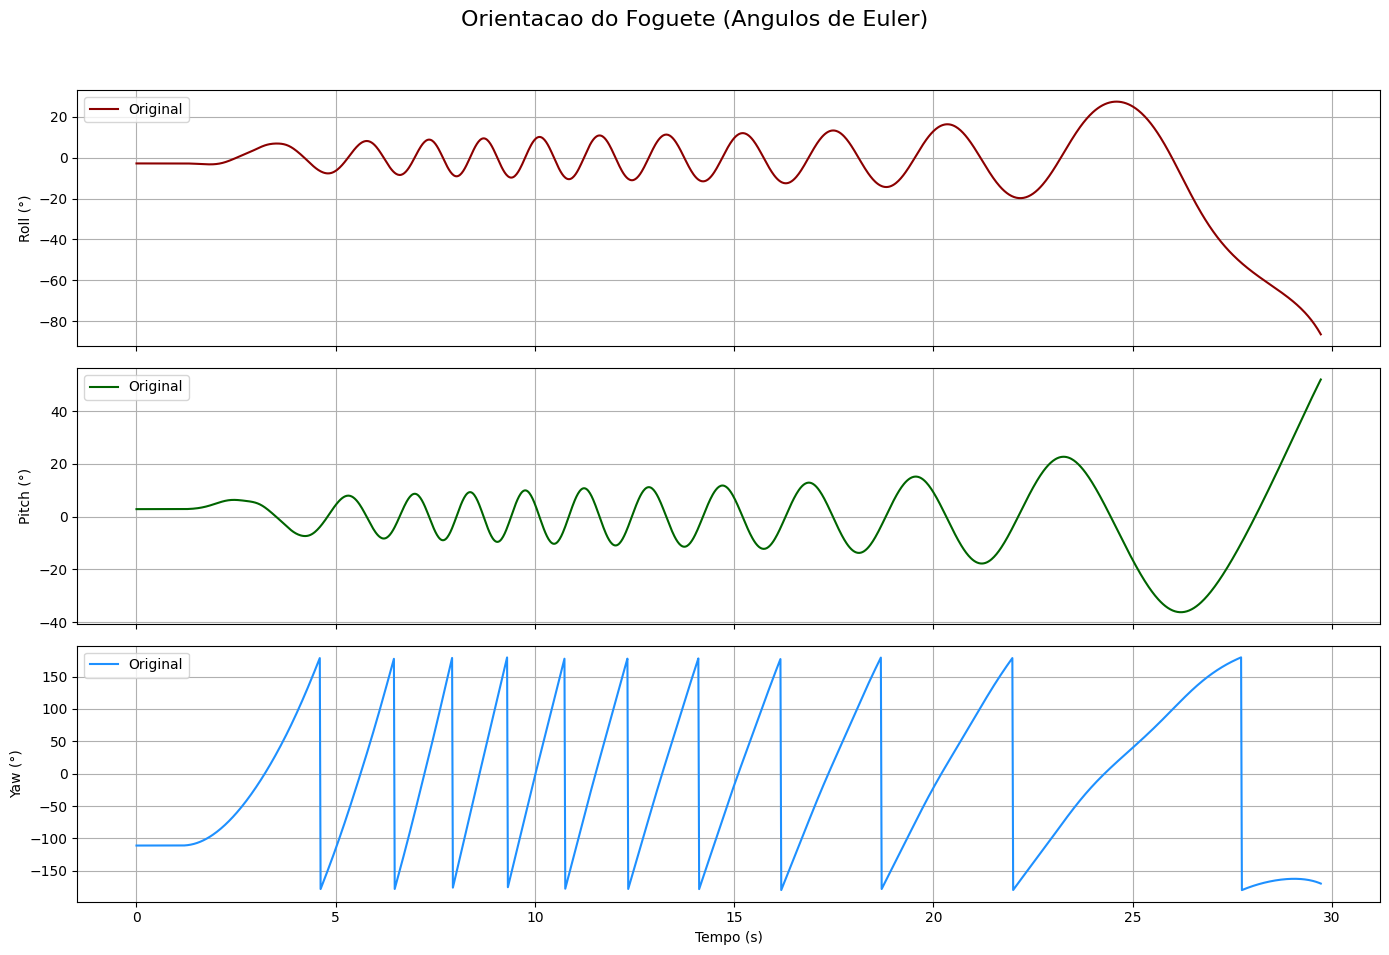

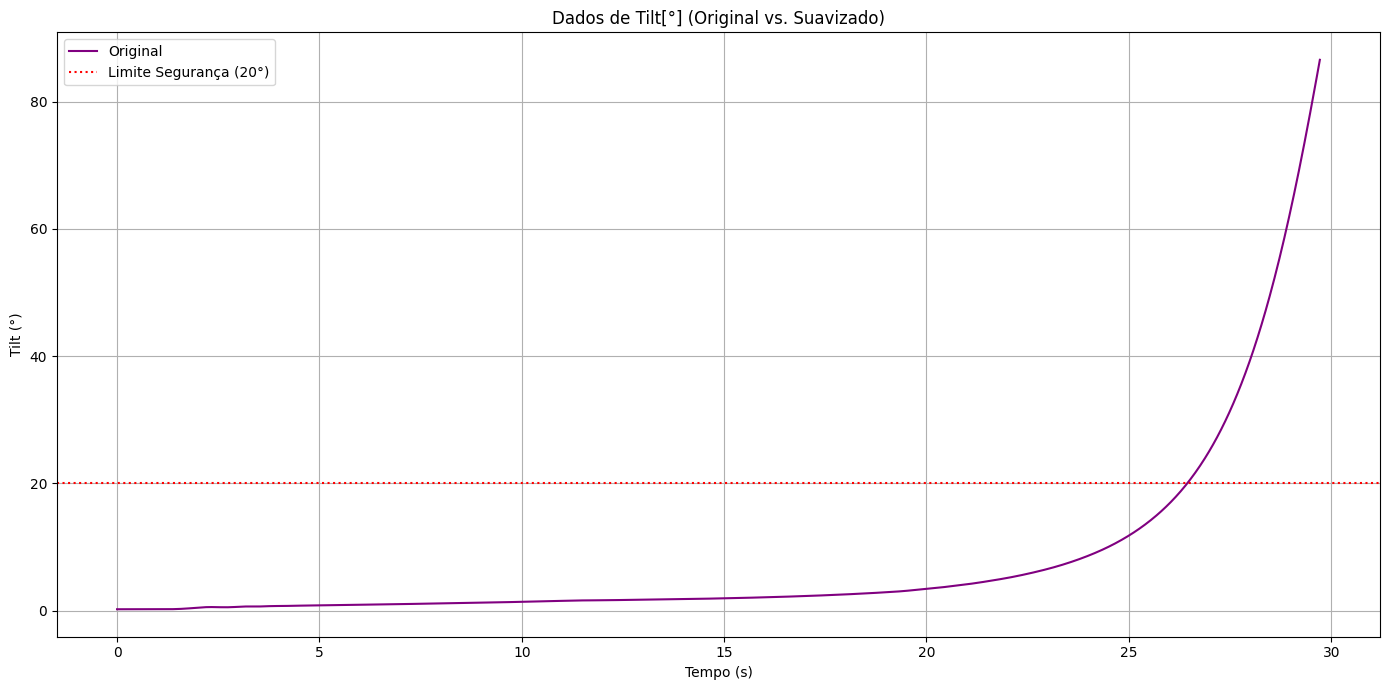

In [42]:
def plot_results(df, window_size=2):

        cols_to_smooth = [
        'accel_x_ms2', 'accel_y_ms2', 'accel_z_ms2',
        'gyro_x_rads', 'gyro_y_rads', 'gyro_z_rads',
        'mag_x_T', 'mag_y_T', 'mag_z_T',
        'pressure_Pa'
        ]

        for col in cols_to_smooth:
                if col in df.columns:
                        df[f'{col}_smooth'] = df[col].rolling(window=window_size, center=True, min_periods=1).mean()



        fig1, axs1 = plt.subplots(3, 1, sharex=True, figsize=(14, 10))
        fig1.suptitle('Cinemática do Voo', fontsize=16)
        # Subplot da Altitude
        axs1[0].plot(df['time'], df['sim_z'], label='Original', color='blue')
        axs1[0].set_ylabel('Altitude (m)')
        axs1[0].grid(True)
        axs1[0].legend(loc='upper left')

        # Subplot da Velocidade
        axs1[1].plot(df['time'], df['sim_vz'], label='Original', color='green')
        axs1[1].set_ylabel('Velocidade (m/s)')
        axs1[1].grid(True)
        axs1[1].legend(loc='upper left')

        # Subplot da Aceleração
        axs1[2].plot(df['time'], df['sim_az'], label='Original', color='red')
        axs1[2].set_ylabel('Aceleracao (m/s^2)')
        axs1[2].set_xlabel(f'Tempo (s)')
        axs1[2].grid(True)
        axs1[2].legend(loc='upper left')
        axs1[2].set_ylim(-50,50)





        # --- GRÁFICO 1: Acelerômetro (g) ---
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        # raw
        # ax1.plot(df['time'], df['accel_x_ms2']/g0, color='blue', alpha=0.25)
        # ax2.plot(df['time'], df['accel_y_ms2']/g0, color='green', alpha=0.25)
        # ax3.plot(df['time'], df['accel_z_ms2']/g0, color='red', alpha=0.25)

        # smooth
        ax1.plot(df['time'], df['accel_x_ms2_smooth']/g0, color='blue', label='Ax (Smooth_sensor)', linewidth=1.5)
        ax2.plot(df['time'], df['accel_y_ms2_smooth']/g0, color='green', label='Ay (Smooth_sensor)', linewidth=1.5)
        ax3.plot(df['time'], df['accel_z_ms2_smooth']/g0, color='red', label='Az (Smooth_sensor)', linewidth=1.5)

        # sim
        ax1.plot(df['time'], df['sim_ax_loc_ms2']/g0, color='blue',label='Ax (Sim)', alpha=0.25)
        ax2.plot(df['time'], df['sim_ay_loc_ms2']/g0, color='green',label='Ay (Sim)', alpha=0.25)
        ax3.plot(df['time'], df['sim_az_loc_ms2']/g0, color='red',label='Az (Sim)', alpha=0.25)

        ax1.set_title(f"Acelerômetro (g) - Janela: {window_size}")
        ax2.set_ylabel("Aceleração [g]")
        plt.xlabel("Tempo (s)")
        plt.ylim(-8, 8)
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax2.legend(loc='upper right')
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax3.legend(loc='upper right')
        ax3.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        # erros
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        erro_ax = df['accel_x_ms2_smooth'] - df['sim_ax_loc_ms2']
        erro_ay = df['accel_y_ms2_smooth'] - df['sim_ay_loc_ms2']
        erro_az = df['accel_z_ms2_smooth'] - df['sim_az_loc_ms2']

        ax1.plot(df['time'], erro_ax, 
                color='blue', linewidth=0.8, label='Erro (Medido - Real)')
        ax2.plot(df['time'], erro_ay, 
                color='green', linewidth=0.8, label='Erro (Medido - Real)')
        ax3.plot(df['time'], erro_az, 
                color='red', linewidth=0.8, label='Erro (Medido - Real)')

        ax1.axhline(0, color='black', linestyle='--', linewidth=1)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        ax3.axhline(0, color='black', linestyle='--', linewidth=1)

        ax3.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Erro (g)")
        ax1.set_title("Resíduos (Ruído + Bias)")
        ax1.grid(True, which='both', linestyle='--', alpha=0.7)
        ax1.legend()
        ax2.grid(True, which='both', linestyle='--', alpha=0.7)
        ax2.legend()
        ax3.grid(True, which='both', linestyle='--', alpha=0.7)
        ax3.legend()
        plt.ylim(-1, 1)

        plt.tight_layout()
        plt.show()

        bias_medio_ax = np.mean(erro_ax)
        bias_medio_ay = np.mean(erro_ay)
        bias_medio_az = np.mean(erro_az)
        std_erro_ax = np.std(erro_ax)
        std_erro_ay = np.std(erro_ay)
        std_erro_az = np.std(erro_az)
        rmse_ax = np.sqrt(np.mean(erro_ax**2))
        rmse_ay = np.sqrt(np.mean(erro_ay**2))
        rmse_az = np.sqrt(np.mean(erro_az**2))

        print(f"--- Estatísticas de Erro do Acelerometro ---")
        print(f"Bias Médio (Erro Sistemático): Ax={bias_medio_ax:.4f} g, Ay={bias_medio_ay:.4f} g, Az={bias_medio_az:.4f} g")
        print(f"Desvio Padrão (Ruído Percebido): Ax={std_erro_ax:.4f} g, Ay={std_erro_ay:.4f} g, Az={std_erro_az:.4f} g")
        print(f"RMSE (Erro Quadrático Médio): Ax={rmse_ax:.4f} g, Ay={rmse_ay:.4f} g, Az={rmse_az:.4f} g")

        # --- GRÁFICO 2: Giroscópio (deg/s) ---
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
        rad2deg = 180 / np.pi

        # raw
        # ax1.plot(df['time'], df['gyro_x_rads']*rad2deg, color='blue', alpha=0.25)
        # ax2.plot(df['time'], df['gyro_y_rads']*rad2deg, color='green', alpha=0.25)
        # ax3.plot(df['time'], df['gyro_z_rads']*rad2deg, color='red', alpha=0.25)

        # smooth
        ax1.plot(df['time'], df['gyro_x_rads_smooth']*rad2deg, color='blue', label='Wx (Smooth_sensor)', linewidth=1.5)
        ax2.plot(df['time'], df['gyro_y_rads_smooth']*rad2deg, color='green', label='Wy (Smooth_sensor)', linewidth=1.5)
        ax3.plot(df['time'], df['gyro_z_rads_smooth']*rad2deg, color='red', label='Wz (Smooth_sensor)', linewidth=1.5)

        # sim
        ax1.plot(df['time'], df['sim_gx_rads']*rad2deg, color='blue',label='Wx (Sim)', alpha=0.25)
        ax2.plot(df['time'], df['sim_gy_rads']*rad2deg, color='green',label='Wy (Sim)', alpha=0.25)
        ax3.plot(df['time'], df['sim_gz_rads']*rad2deg, color='red',label='Wz (Sim)', alpha=0.25)

        ax1.set_title("Giroscópio (deg/s)")
        ax2.set_ylabel("Vel. Angular [deg/s]")
        plt.xlabel("Tempo (s)")
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax2.legend(loc='upper right')
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax3.legend(loc='upper right')
        ax3.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        # erros
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        erro_gx = df['gyro_x_rads_smooth']*rad2deg - df['sim_gx_rads']*rad2deg
        erro_gy = df['gyro_y_rads_smooth']*rad2deg - df['sim_gy_rads']*rad2deg
        erro_gz = df['gyro_z_rads_smooth']*rad2deg - df['sim_gz_rads']*rad2deg

        ax1.plot(df['time'], erro_gx, 
                color='blue', linewidth=0.8, label='Erro (Medido - Real)')
        ax2.plot(df['time'], erro_gy, 
                color='green', linewidth=0.8, label='Erro (Medido - Real)')
        ax3.plot(df['time'], erro_gz, 
                color='red', linewidth=0.8, label='Erro (Medido - Real)')

        ax1.axhline(0, color='black', linestyle='--', linewidth=1)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        ax3.axhline(0, color='black', linestyle='--', linewidth=1)

        ax3.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Erro (degs)")
        ax1.set_title("Resíduos (Ruído + Bias)")
        ax1.grid(True, which='both', linestyle='--', alpha=0.7)
        ax1.legend()
        ax2.grid(True, which='both', linestyle='--', alpha=0.7)
        ax2.legend()
        ax3.grid(True, which='both', linestyle='--', alpha=0.7)
        ax3.legend()

        plt.tight_layout()
        plt.show()
        bias_medio_gx = np.mean(erro_gx)
        bias_medio_gy = np.mean(erro_gy)
        bias_medio_gz = np.mean(erro_gz)
        std_erro_gx = np.std(erro_gx)
        std_erro_gy = np.std(erro_gy)
        std_erro_gz = np.std(erro_gz)
        rmse_gx = np.sqrt(np.mean(erro_gx**2))
        rmse_gy = np.sqrt(np.mean(erro_gy**2))
        rmse_gz = np.sqrt(np.mean(erro_gz**2))

        print(f"--- Estatísticas de Erro do Giroscopio ---")
        print(f"Bias Médio (Erro Sistemático): gx={bias_medio_gx:.4f} deg/s, gy={bias_medio_gy:.4f} deg/s, gz={bias_medio_gz:.4f} deg/s")
        print(f"Desvio Padrão (Ruído Percebido): gx={std_erro_gx:.4f} deg/s, gy={std_erro_gy:.4f} deg/s, gz={std_erro_gz:.4f} deg/s")
        print(f"RMSE (Erro Quadrático Médio): gx={rmse_gx:.4f} deg/s, gy={rmse_gy:.4f} deg/s, gz={rmse_gz:.4f} deg/s")

        # --- GRÁFICO 3: Magnetômetro (uT) ---
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
        t2uT = 1e6

        # raw
        # plt.plot(df['time'], df['mag_x_T']*t2uT, color='blue', alpha=0.25)
        # plt.plot(df['time'], df['mag_y_T']*t2uT, color='green', alpha=0.25)
        # plt.plot(df['time'], df['mag_z_T']*t2uT, color='red', alpha=0.25)

        # smooth
        ax1.plot(df['time'], df['mag_x_T_smooth']*t2uT, color='blue', label='Mx (Smooth_sensor)', linewidth=1.5)
        ax2.plot(df['time'], df['mag_y_T_smooth']*t2uT, color='green', label='My (Smooth_sensor)', linewidth=1.5)
        ax3.plot(df['time'], df['mag_z_T_smooth']*t2uT, color='red', label='Mz (Smooth_sensor)', linewidth=1.5)

        # sim
        ax1.plot(df['time'], df['sim_mx_T']*t2uT, color='blue',label='Mx (Sim)', alpha=0.25)
        ax2.plot(df['time'], df['sim_my_T']*t2uT, color='green',label='My (Sim)', alpha=0.25)
        ax3.plot(df['time'], df['sim_mz_T']*t2uT, color='red',label='Mz (Sim)', alpha=0.25)

        ax1.set_title("Magnetômetro (uT)")
        ax2.set_ylabel("Campo Magnético [uT]")
        plt.xlabel("Tempo (s)")
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax2.legend(loc='upper right')
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax3.legend(loc='upper right')
        ax3.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        # erros
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        erro_mx = df['mag_x_T_smooth']*t2uT - df['sim_mx_T']*t2uT
        erro_my = df['mag_y_T_smooth']*t2uT - df['sim_my_T']*t2uT
        erro_mz = df['mag_z_T_smooth']*t2uT - df['sim_mz_T']*t2uT

        ax1.plot(df['time'], erro_mx, 
                color='blue', linewidth=0.8, label='Erro (Medido - Real)')
        ax2.plot(df['time'], erro_my, 
                color='green', linewidth=0.8, label='Erro (Medido - Real)')
        ax3.plot(df['time'], erro_mz, 
                color='red', linewidth=0.8, label='Erro (Medido - Real)')

        ax1.axhline(0, color='black', linestyle='--', linewidth=1)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        ax3.axhline(0, color='black', linestyle='--', linewidth=1)

        ax3.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Erro (uT)")
        ax1.set_title("Resíduos (Ruído + Bias)")
        ax1.grid(True, which='both', linestyle='--', alpha=0.7)
        ax1.legend()
        ax2.grid(True, which='both', linestyle='--', alpha=0.7)
        ax2.legend()
        ax3.grid(True, which='both', linestyle='--', alpha=0.7)
        ax3.legend()

        plt.tight_layout()
        plt.show()
        bias_medio_mx = np.mean(erro_mx)
        bias_medio_my = np.mean(erro_my)
        bias_medio_mz = np.mean(erro_mz)
        std_erro_mx = np.std(erro_mx)
        std_erro_my = np.std(erro_my)
        std_erro_mz = np.std(erro_mz)
        rmse_mx = np.sqrt(np.mean(erro_mx**2))
        rmse_my = np.sqrt(np.mean(erro_my**2))
        rmse_mz = np.sqrt(np.mean(erro_mz**2))

        print(f"--- Estatísticas de Erro do Magnetometro ---")
        print(f"Bias Médio (Erro Sistemático): mx={bias_medio_mx:.4f} uT, my={bias_medio_my:.4f} uT, mz={bias_medio_mz:.4f} uT")
        print(f"Desvio Padrão (Ruído Percebido): mx={std_erro_mx:.4f} uT, my={std_erro_my:.4f} uT, mz={std_erro_mz:.4f} uT")
        print(f"RMSE (Erro Quadrático Médio): mx={rmse_mx:.4f} uT, my={rmse_my:.4f} uT, mz={rmse_mz:.4f} uT")

        # --- GRÁFICO 4: Barômetro (Pa) ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        # raw
        # plt.plot(df['time'], df['pressure_Pa'], color='orange', alpha=0.3, label='Raw')

        # smooth
        ax1.plot(df['time'], df['pressure_Pa_smooth'], color='orange', label='Pressure (Smooth_sensor)', linewidth=1.5)
        ax1.plot(df['time'], df['sim_pressure_Pa'], color='orange', label='Pressure (Sim)', alpha=0.25)


        ax1.set_title("Barômetro (Pa)")
        ax1.set_ylabel("Pressão [Pa]")
        ax1.set_xlabel("Tempo (s)")
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.6)

        erro_pressao = df['pressure_Pa_smooth'] - df['sim_pressure_Pa']

        ax2.plot(df['time'], erro_pressao, 
                color='blue', linewidth=0.8, label='Erro (Medido - Real)')

        ax2.axhline(0, color='black', linestyle='--', linewidth=1)

        ax2.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Erro (Pa)")
        ax2.set_title("Resíduos (Ruído + Bias)")
        ax2.grid(True, which='both', linestyle='--', alpha=0.7)
        ax2.legend()

        plt.tight_layout()
        plt.show()

        bias_medio = np.mean(erro_pressao)
        std_erro = np.std(erro_pressao)
        rmse = np.sqrt(np.mean(erro_pressao**2))

        print(f"--- Estatísticas de Erro do Barômetro ---")
        print(f"Bias Médio (Erro Sistemático): {bias_medio:.4f} Pa")
        print(f"Desvio Padrão (Ruído Percebido): {std_erro:.4f} Pa")
        print(f"RMSE (Erro Quadrático Médio): {rmse:.4f} Pa")

        # --- Função de Conversão de Quaternion para Euler ---
        def calcular_euler_angles(df_in, prefix=''):
                """Calcula Roll, Pitch, Yaw a partir das colunas de quaternion."""
                qw = df_in[f'sim_q0{prefix}']
                qx = df_in[f'sim_q1{prefix}']
                qy = df_in[f'sim_q2{prefix}']
                qz = df_in[f'sim_q3{prefix}']

                # Roll (rotação em torno do eixo X do corpo)
                sinr_cosp = 2 * (qw * qx + qy * qz)
                cosr_cosp = 1 - 2 * (qx**2 + qy**2)
                df_in[f'Roll_deg{prefix}'] = np.arctan2(sinr_cosp, cosr_cosp) * (180.0 / np.pi)

                # Pitch (rotação em torno do eixo Y do corpo)
                sinp = 2 * (qw * qy - qz * qx)
                sinp = np.clip(sinp, -1.0, 1.0) # Clamp para evitar erros de domínio em arcsin
                df_in[f'Pitch_deg{prefix}'] = np.arcsin(sinp) * (180.0 / np.pi)

                # Yaw (rotação em torno do eixo Z do corpo)
                siny_cosp = 2 * (qw * qz + qx * qy)
                cosy_cosp = 1 - 2 * (qy**2 + qz**2)
                df_in[f'Yaw_deg{prefix}'] = np.arctan2(siny_cosp, cosy_cosp) * (180.0 / np.pi)


        # Calcula os ângulos de Euler para os dados originais e suavizados
        if all(col in df.columns for col in ['sim_q0', 'sim_q0', 'sim_q0', 'sim_q0']):
                # Calcula a partir dos quaternions originais
                calcular_euler_angles(df) 
                # # Calcula a partir dos quaternions suavizados (da média móvel)
                # calcular_euler_angles(df, prefix='_smooth') 
        else:
                print("Aviso: Colunas de quaternion nao encontradas. Graficos de Euler nao serao gerados.")

        if all(col in df.columns for col in ['Roll_deg', 'Pitch_deg', 'Yaw_deg']):
                fig_euler, axs_euler = plt.subplots(3, 1, sharex=True, figsize=(14, 10))
                fig_euler.suptitle('Orientacao do Foguete (Angulos de Euler)', fontsize=16)

                # Subplot do Roll
                axs_euler[0].plot(df['time'], df['Roll_deg'], label='Original', color='darkred')
                axs_euler[0].set_ylabel('Roll (°)')
                axs_euler[0].grid(True)
                axs_euler[0].legend(loc='upper left')

                # Subplot do Pitch
                axs_euler[1].plot(df['time'], df['Pitch_deg'], label='Original', color='darkgreen')
                axs_euler[1].set_ylabel('Pitch (°)')
                axs_euler[1].grid(True)
                axs_euler[1].legend(loc='upper left')

                # Subplot do Yaw
                axs_euler[2].plot(df['time'], df['Yaw_deg'], label='Original', color='dodgerblue')
                axs_euler[2].set_ylabel('Yaw (°)')
                axs_euler[2].set_xlabel(f'Tempo (s)')
                axs_euler[2].grid(True)
                axs_euler[2].legend(loc='upper left')

                plt.tight_layout(rect=[0, 0.03, 1, 0.95])

                # --- GRÁFICO 6: Tilt (Deg) ---
                plt.figure(figsize=(14, 7))
                plt.plot(df['time'], df['sim_tilt'], label='Original', color='purple')
                plt.axhline(20, color='red', linestyle=':', label='Limite Segurança (20°)')
                plt.title('Dados de Tilt[°] (Original vs. Suavizado)')
                plt.xlabel(f'Tempo (s)')
                plt.ylabel('Tilt (°)')
                plt.legend()
                plt.grid(True)
                plt.tight_layout()

    

plot_results(df_final, window_size=4)

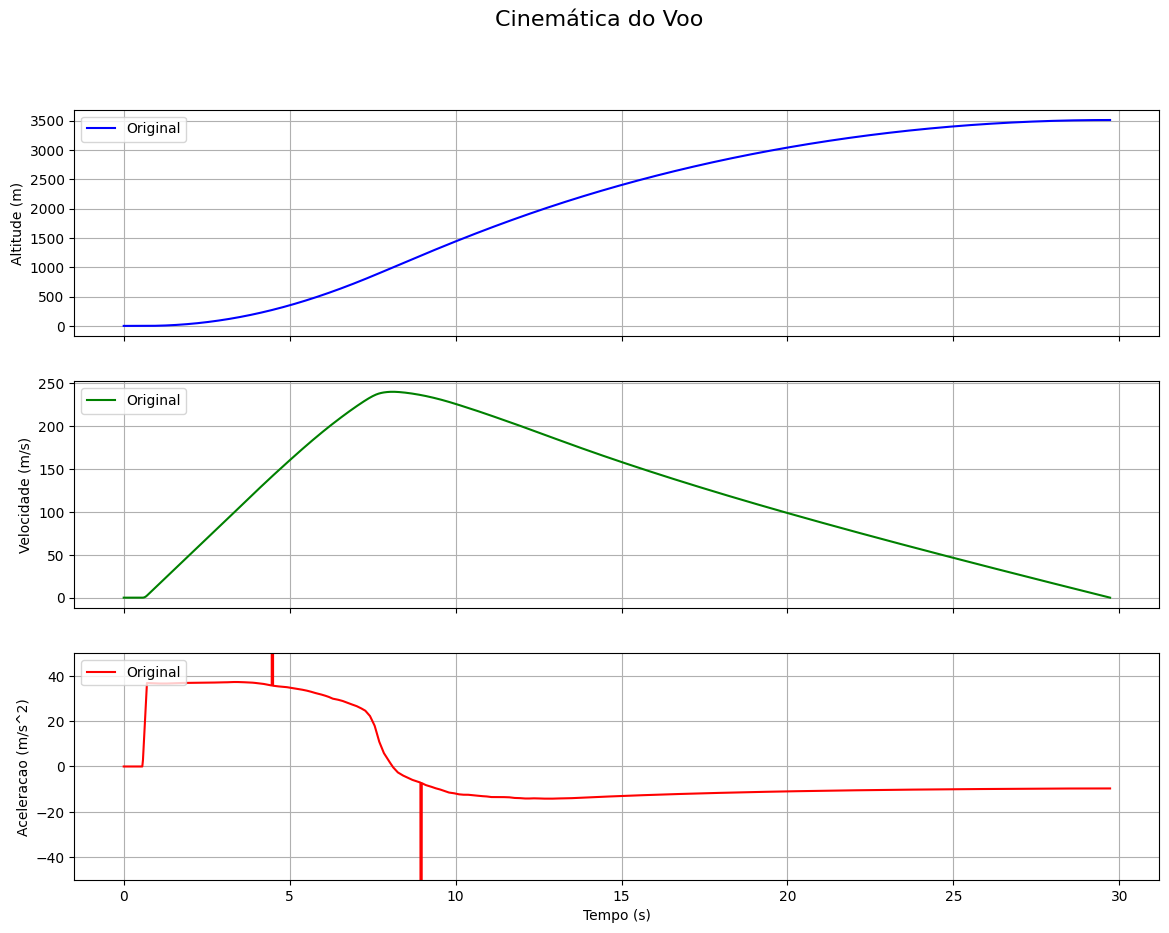

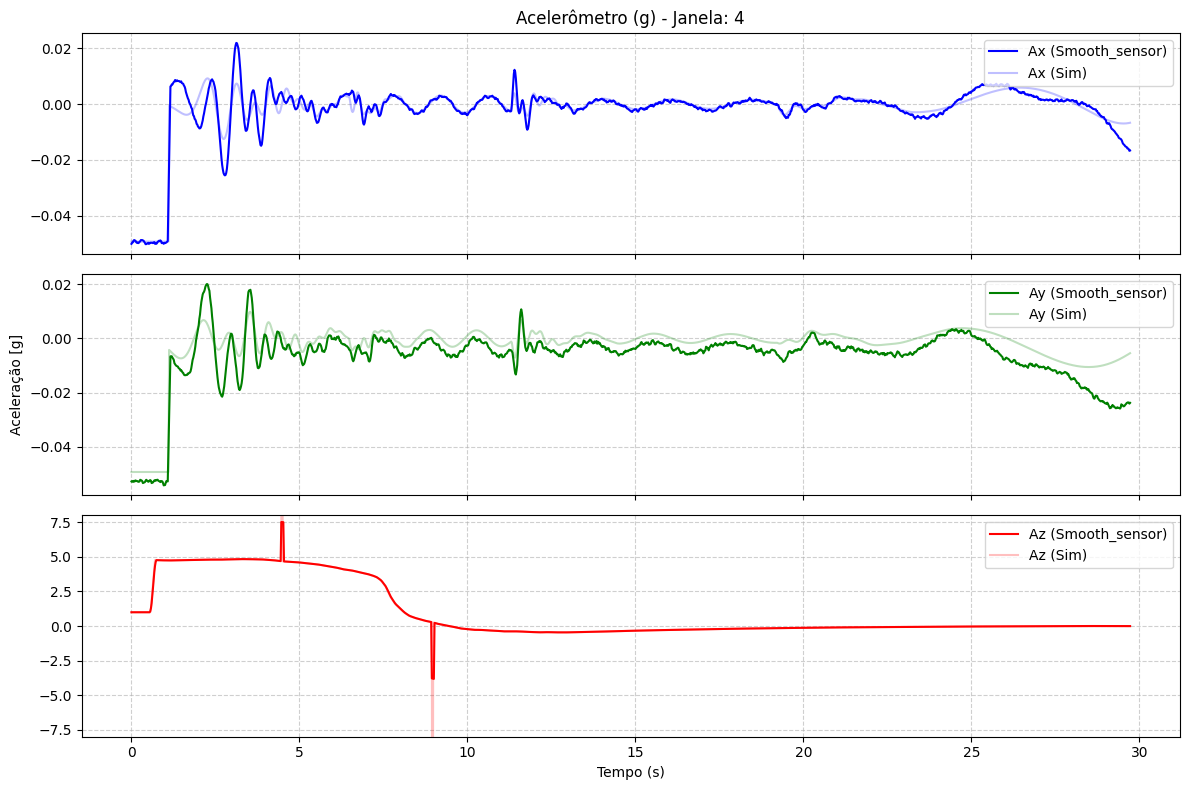

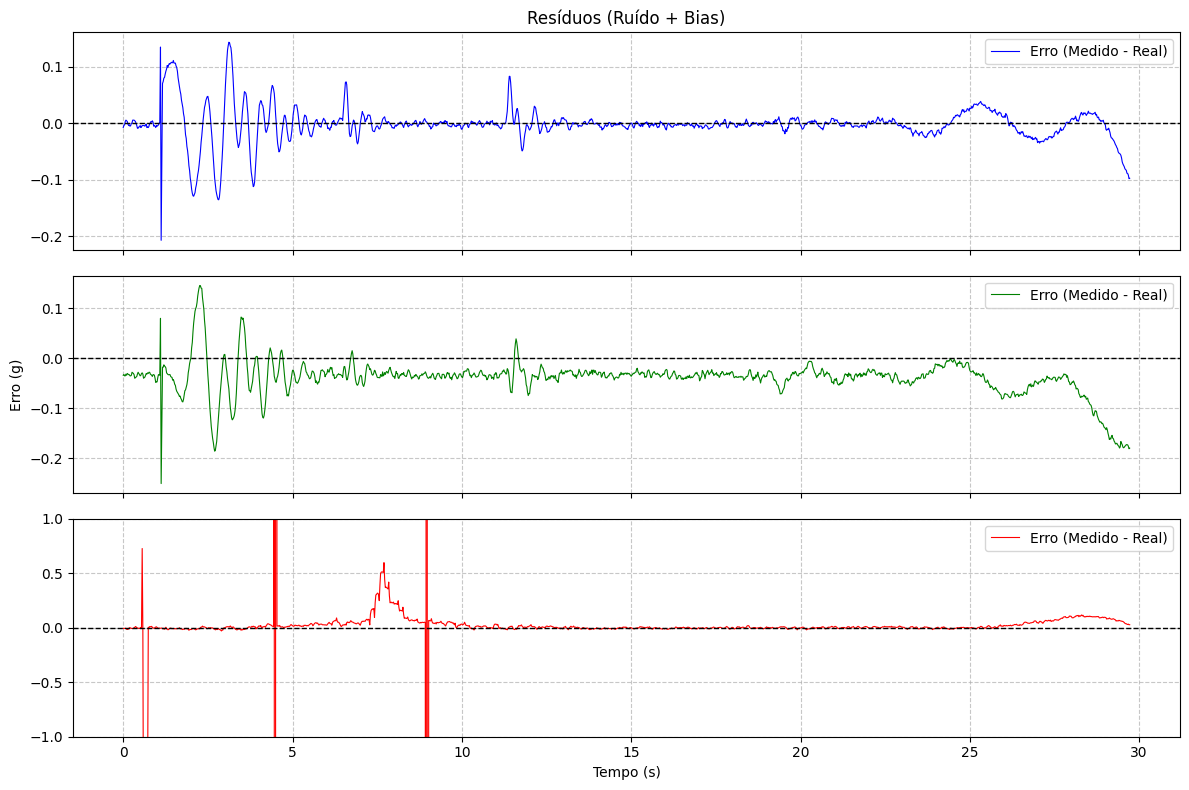

--- Estatísticas de Erro do Acelerometro ---
Bias Médio (Erro Sistemático): Ax=-0.0018 g, Ay=-0.0396 g, Az=-0.1900 g
Desvio Padrão (Ruído Percebido): Ax=0.0304 g, Ay=0.0368 g, Az=18.6467 g
RMSE (Erro Quadrático Médio): Ax=0.0305 g, Ay=0.0541 g, Az=18.6476 g


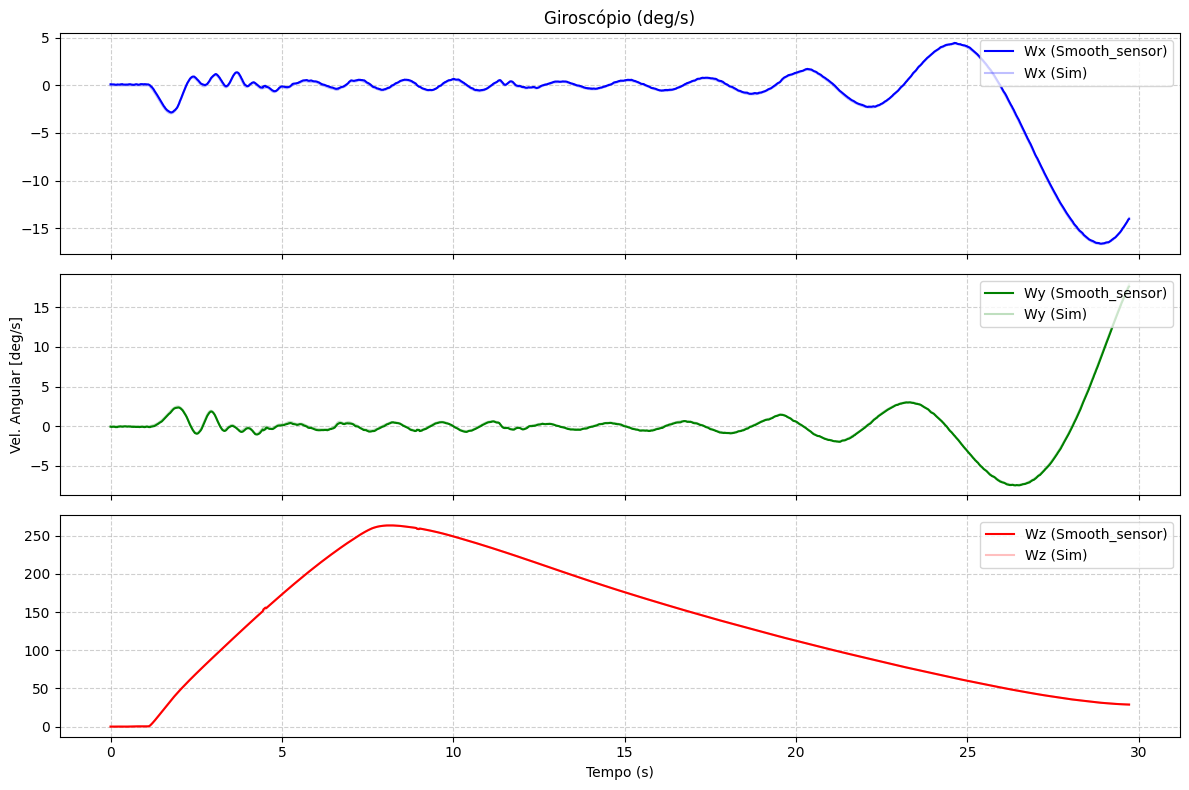

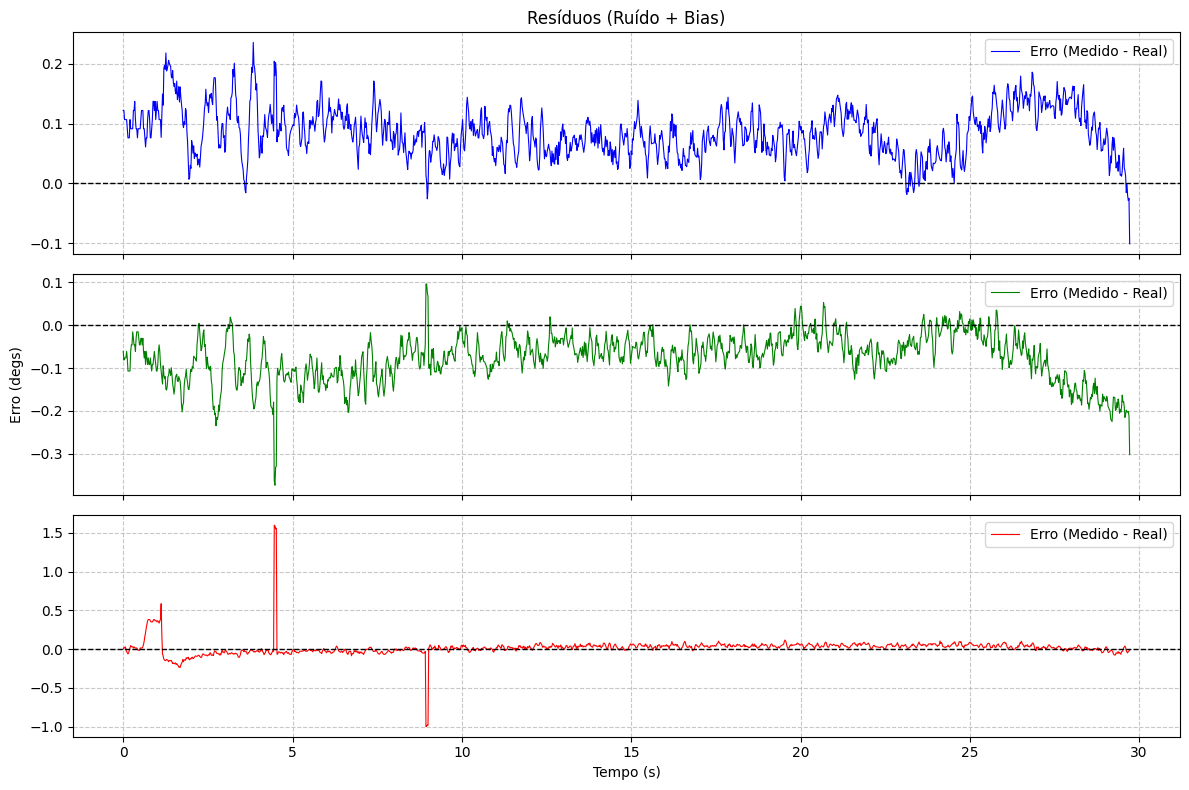

--- Estatísticas de Erro do Giroscopio ---
Bias Médio (Erro Sistemático): gx=0.0851 deg/s, gy=-0.0757 deg/s, gz=0.0180 deg/s
Desvio Padrão (Ruído Percebido): gx=0.0406 deg/s, gy=0.0543 deg/s, gz=0.1173 deg/s
RMSE (Erro Quadrático Médio): gx=0.0943 deg/s, gy=0.0931 deg/s, gz=0.1187 deg/s


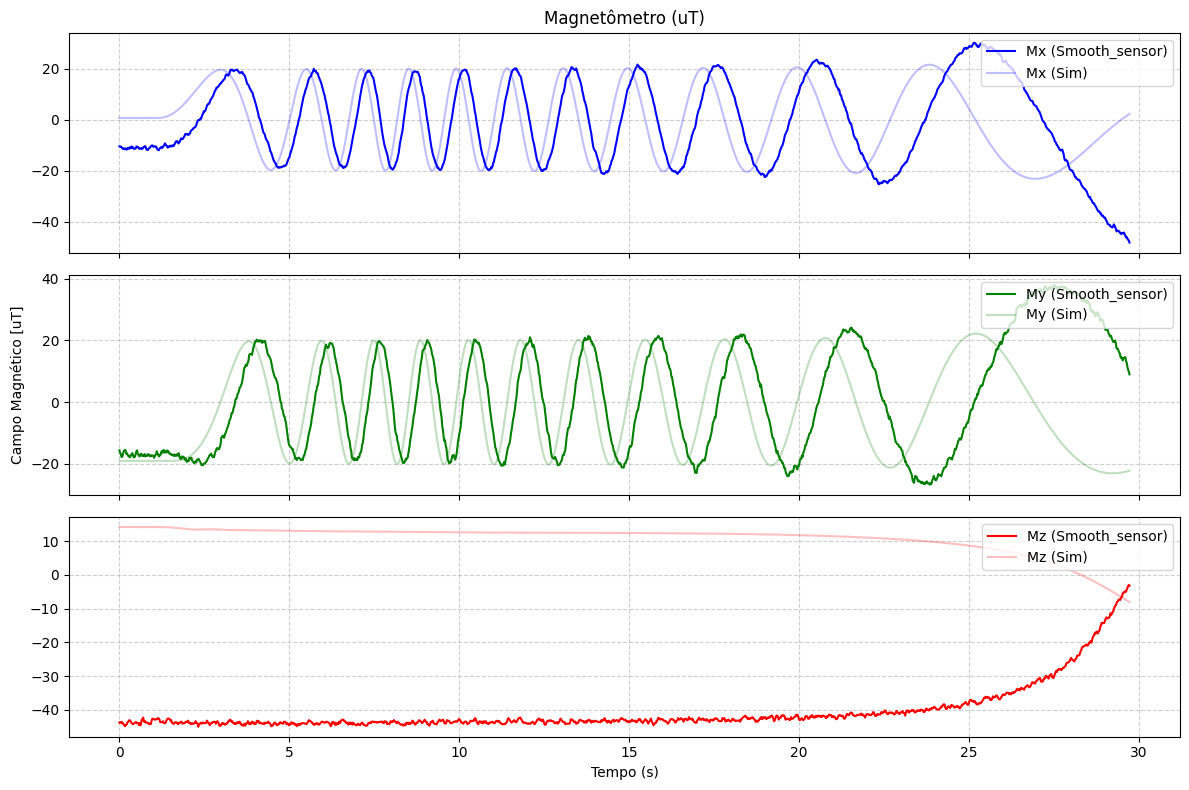

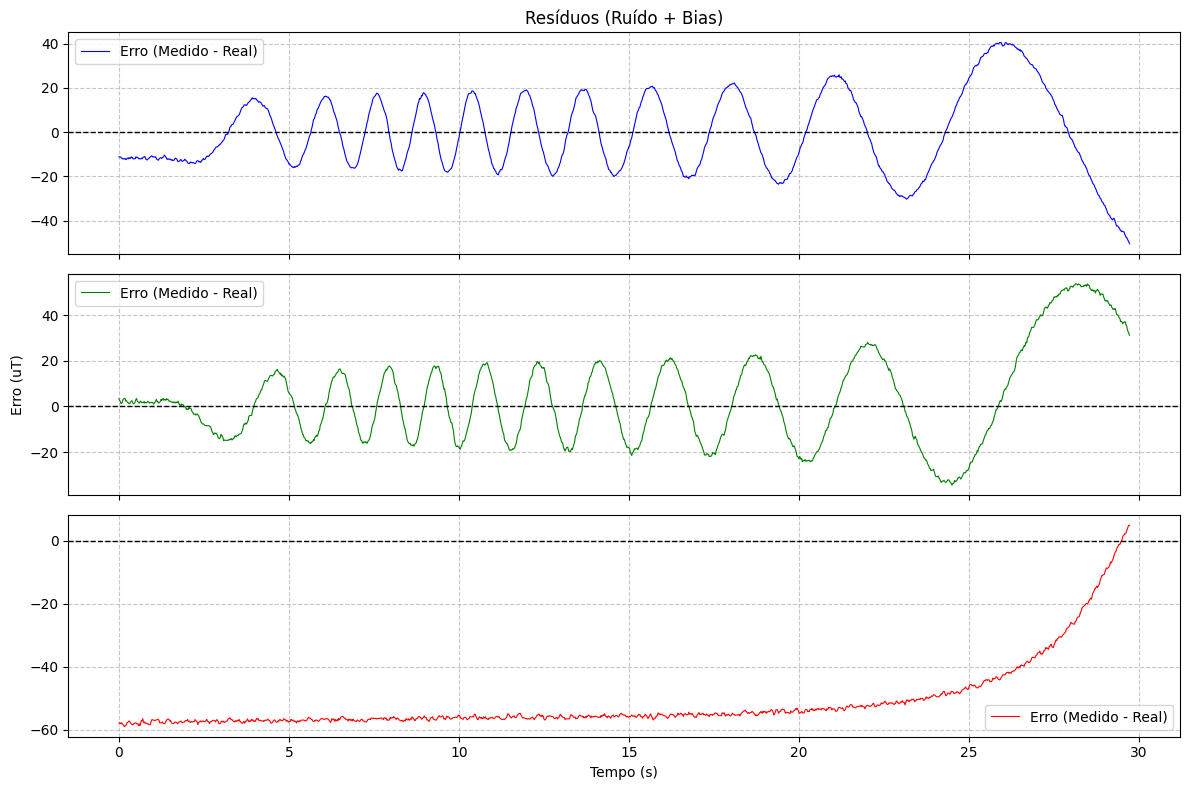

--- Estatísticas de Erro do Magnetometro ---
Bias Médio (Erro Sistemático): mx=-0.3704 uT, my=3.5038 uT, mz=-51.1197 uT
Desvio Padrão (Ruído Percebido): mx=18.0611 uT, my=20.1325 uT, mz=11.4636 uT
RMSE (Erro Quadrático Médio): mx=18.0649 uT, my=20.4352 uT, mz=52.3893 uT


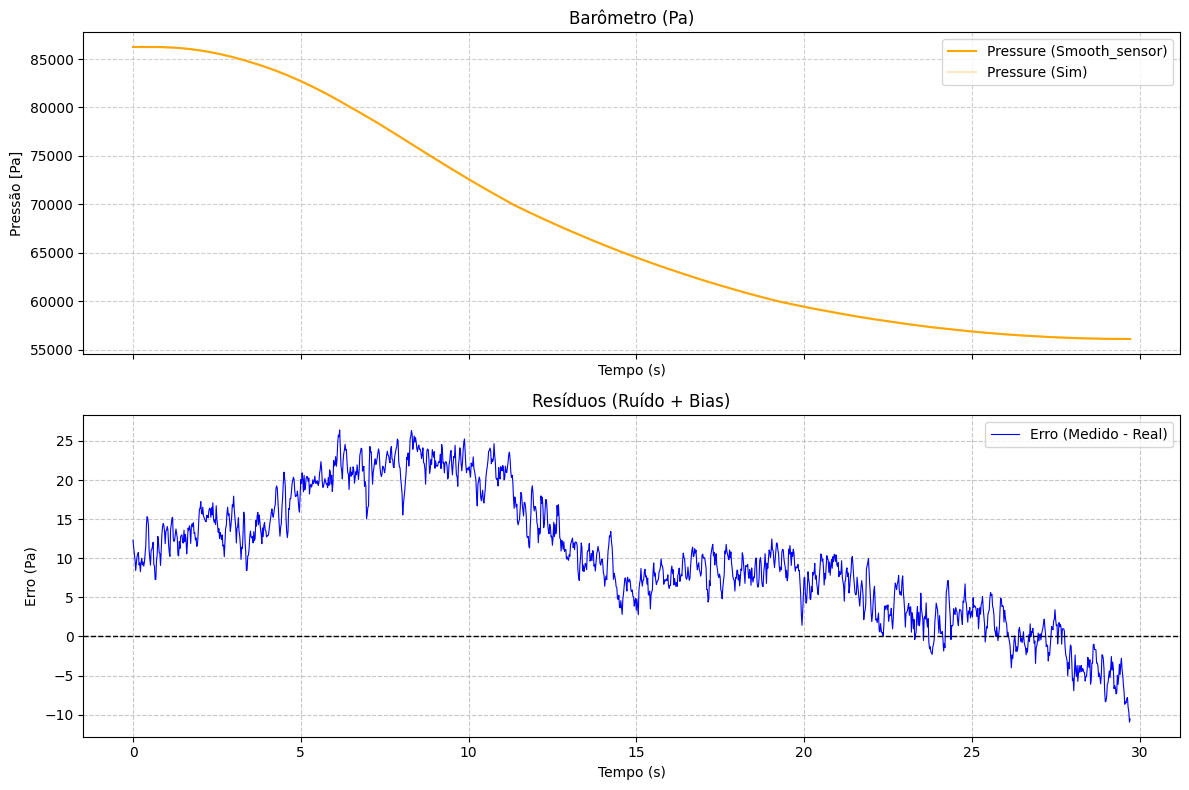

--- Estatísticas de Erro do Barômetro ---
Bias Médio (Erro Sistemático): 10.2638 Pa
Desvio Padrão (Ruído Percebido): 8.0811 Pa
RMSE (Erro Quadrático Médio): 13.0633 Pa


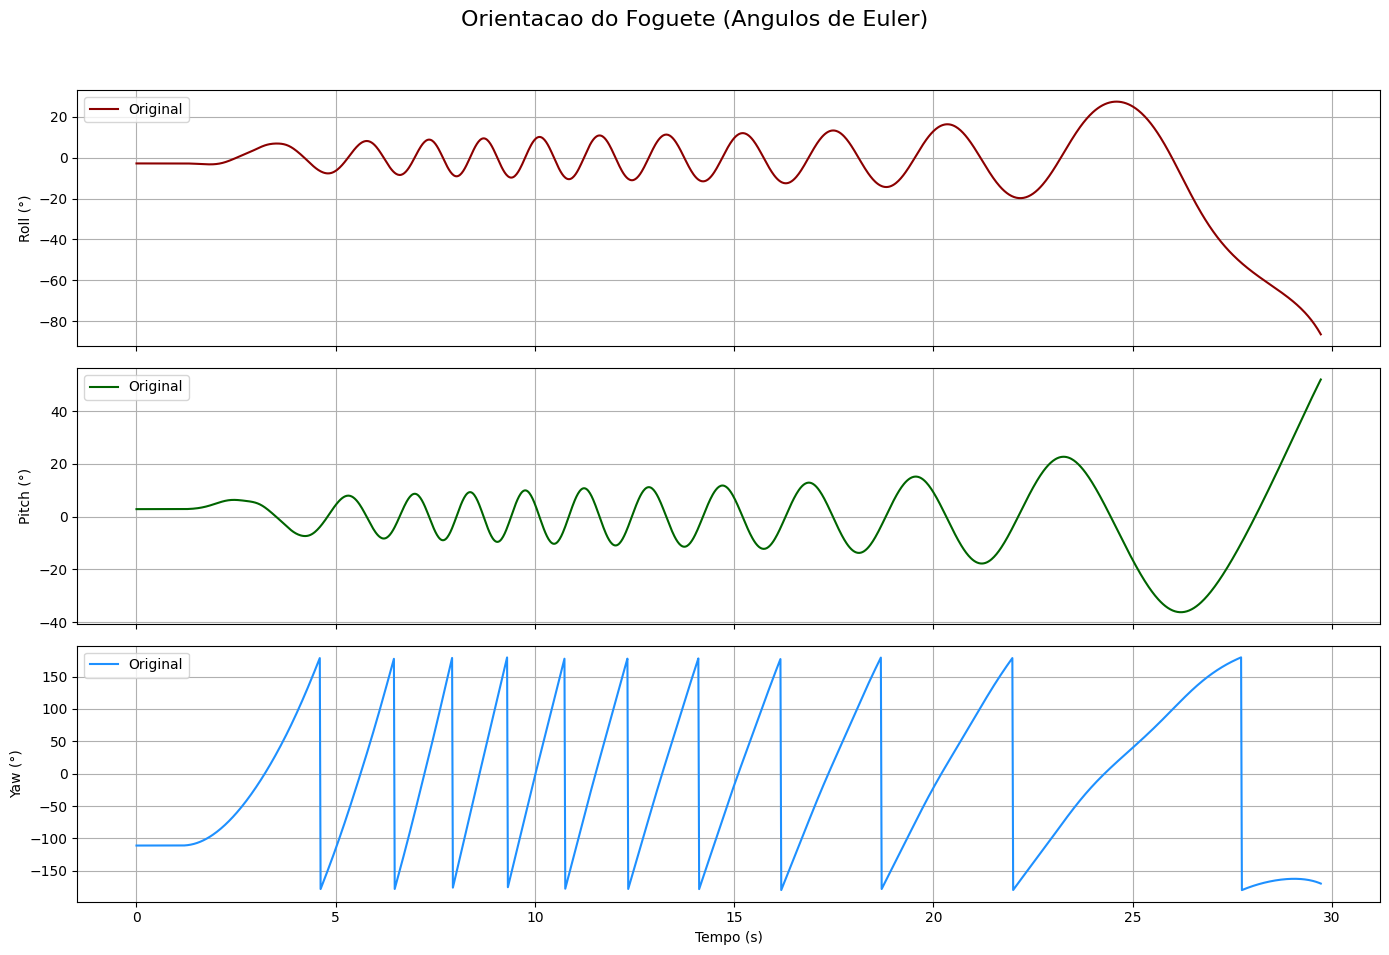

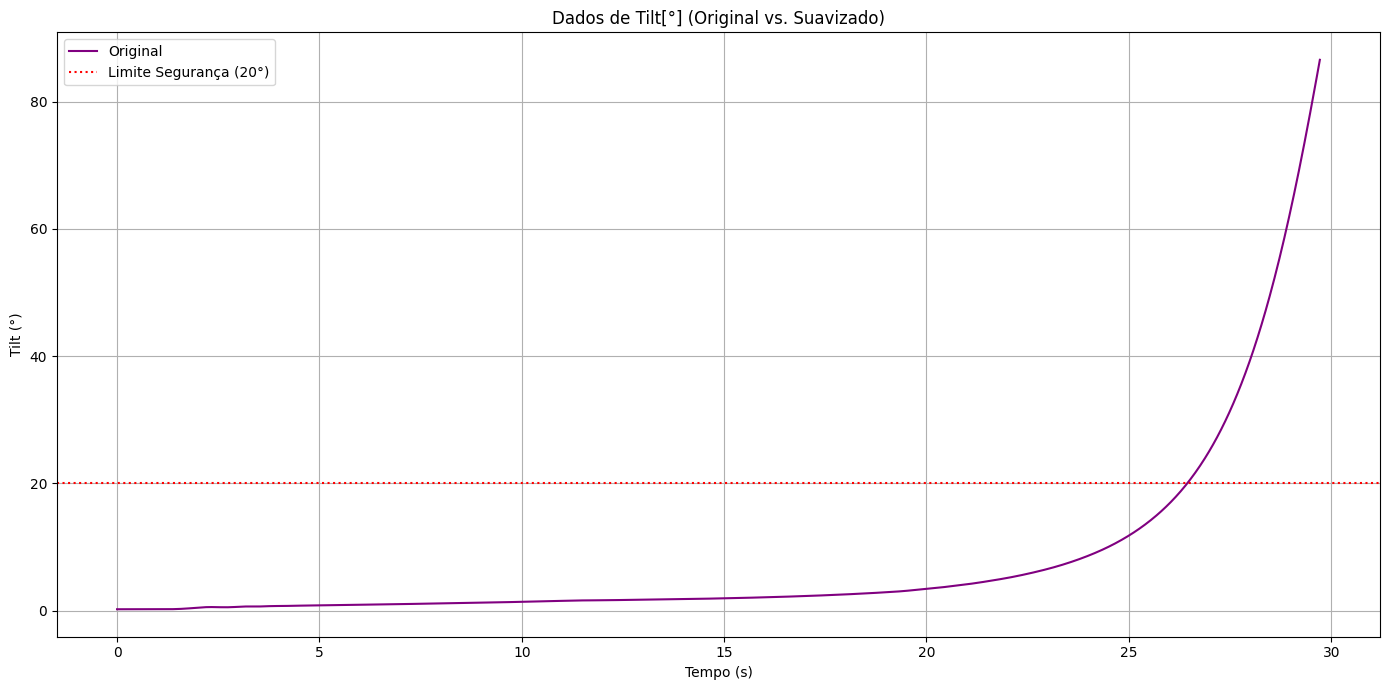

In [43]:
def plot_results(df, window_size=2):

        cols_to_smooth = [
        'accel_x_ms2', 'accel_y_ms2', 'accel_z_ms2',
        'gyro_x_rads', 'gyro_y_rads', 'gyro_z_rads',
        'mag_x_T', 'mag_y_T', 'mag_z_T',
        'pressure_Pa'
        ]

        for col in cols_to_smooth:
                if col in df.columns:
                        df[f'{col}_smooth'] = df[col].rolling(window=window_size, center=True, min_periods=1).mean()



        fig1, axs1 = plt.subplots(3, 1, sharex=True, figsize=(14, 10))
        fig1.suptitle('Cinemática do Voo', fontsize=16)
        # Subplot da Altitude
        axs1[0].plot(df['time'], df['sim_z'], label='Original', color='blue')
        axs1[0].set_ylabel('Altitude (m)')
        axs1[0].grid(True)
        axs1[0].legend(loc='upper left')

        # Subplot da Velocidade
        axs1[1].plot(df['time'], df['sim_vz'], label='Original', color='green')
        axs1[1].set_ylabel('Velocidade (m/s)')
        axs1[1].grid(True)
        axs1[1].legend(loc='upper left')

        # Subplot da Aceleração
        axs1[2].plot(df['time'], df['sim_az'], label='Original', color='red')
        axs1[2].set_ylabel('Aceleracao (m/s^2)')
        axs1[2].set_xlabel(f'Tempo (s)')
        axs1[2].grid(True)
        axs1[2].legend(loc='upper left')
        axs1[2].set_ylim(-50,50)





        # --- GRÁFICO 1: Acelerômetro (g) ---
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        # raw
        # ax1.plot(df['time'], df['accel_x_ms2']/g0, color='blue', alpha=0.25)
        # ax2.plot(df['time'], df['accel_y_ms2']/g0, color='green', alpha=0.25)
        # ax3.plot(df['time'], df['accel_z_ms2']/g0, color='red', alpha=0.25)

        # smooth
        ax1.plot(df['time'], df['accel_x_ms2_smooth']/g0, color='blue', label='Ax (Smooth_sensor)', linewidth=1.5)
        ax2.plot(df['time'], df['accel_y_ms2_smooth']/g0, color='green', label='Ay (Smooth_sensor)', linewidth=1.5)
        ax3.plot(df['time'], df['accel_z_ms2_smooth']/g0, color='red', label='Az (Smooth_sensor)', linewidth=1.5)

        # sim
        ax1.plot(df['time'], df['sim_ax_loc_ms2']/g0, color='blue',label='Ax (Sim)', alpha=0.25)
        ax2.plot(df['time'], df['sim_ay_loc_ms2']/g0, color='green',label='Ay (Sim)', alpha=0.25)
        ax3.plot(df['time'], df['sim_az_loc_ms2']/g0, color='red',label='Az (Sim)', alpha=0.25)

        ax1.set_title(f"Acelerômetro (g) - Janela: {window_size}")
        ax2.set_ylabel("Aceleração [g]")
        plt.xlabel("Tempo (s)")
        plt.ylim(-8, 8)
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax2.legend(loc='upper right')
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax3.legend(loc='upper right')
        ax3.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        # erros
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        erro_ax = df['accel_x_ms2_smooth'] - df['sim_ax_loc_ms2']
        erro_ay = df['accel_y_ms2_smooth'] - df['sim_ay_loc_ms2']
        erro_az = df['accel_z_ms2_smooth'] - df['sim_az_loc_ms2']

        ax1.plot(df['time'], erro_ax, 
                color='blue', linewidth=0.8, label='Erro (Medido - Real)')
        ax2.plot(df['time'], erro_ay, 
                color='green', linewidth=0.8, label='Erro (Medido - Real)')
        ax3.plot(df['time'], erro_az, 
                color='red', linewidth=0.8, label='Erro (Medido - Real)')

        ax1.axhline(0, color='black', linestyle='--', linewidth=1)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        ax3.axhline(0, color='black', linestyle='--', linewidth=1)

        ax3.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Erro (g)")
        ax1.set_title("Resíduos (Ruído + Bias)")
        ax1.grid(True, which='both', linestyle='--', alpha=0.7)
        ax1.legend()
        ax2.grid(True, which='both', linestyle='--', alpha=0.7)
        ax2.legend()
        ax3.grid(True, which='both', linestyle='--', alpha=0.7)
        ax3.legend()
        plt.ylim(-1, 1)

        plt.tight_layout()
        plt.show()

        bias_medio_ax = np.mean(erro_ax)
        bias_medio_ay = np.mean(erro_ay)
        bias_medio_az = np.mean(erro_az)
        std_erro_ax = np.std(erro_ax)
        std_erro_ay = np.std(erro_ay)
        std_erro_az = np.std(erro_az)
        rmse_ax = np.sqrt(np.mean(erro_ax**2))
        rmse_ay = np.sqrt(np.mean(erro_ay**2))
        rmse_az = np.sqrt(np.mean(erro_az**2))

        print(f"--- Estatísticas de Erro do Acelerometro ---")
        print(f"Bias Médio (Erro Sistemático): Ax={bias_medio_ax:.4f} g, Ay={bias_medio_ay:.4f} g, Az={bias_medio_az:.4f} g")
        print(f"Desvio Padrão (Ruído Percebido): Ax={std_erro_ax:.4f} g, Ay={std_erro_ay:.4f} g, Az={std_erro_az:.4f} g")
        print(f"RMSE (Erro Quadrático Médio): Ax={rmse_ax:.4f} g, Ay={rmse_ay:.4f} g, Az={rmse_az:.4f} g")

        # --- GRÁFICO 2: Giroscópio (deg/s) ---
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
        rad2deg = 180 / np.pi

        # raw
        # ax1.plot(df['time'], df['gyro_x_rads']*rad2deg, color='blue', alpha=0.25)
        # ax2.plot(df['time'], df['gyro_y_rads']*rad2deg, color='green', alpha=0.25)
        # ax3.plot(df['time'], df['gyro_z_rads']*rad2deg, color='red', alpha=0.25)

        # smooth
        ax1.plot(df['time'], df['gyro_x_rads_smooth']*rad2deg, color='blue', label='Wx (Smooth_sensor)', linewidth=1.5)
        ax2.plot(df['time'], df['gyro_y_rads_smooth']*rad2deg, color='green', label='Wy (Smooth_sensor)', linewidth=1.5)
        ax3.plot(df['time'], df['gyro_z_rads_smooth']*rad2deg, color='red', label='Wz (Smooth_sensor)', linewidth=1.5)

        # sim
        ax1.plot(df['time'], df['sim_gx_rads']*rad2deg, color='blue',label='Wx (Sim)', alpha=0.25)
        ax2.plot(df['time'], df['sim_gy_rads']*rad2deg, color='green',label='Wy (Sim)', alpha=0.25)
        ax3.plot(df['time'], df['sim_gz_rads']*rad2deg, color='red',label='Wz (Sim)', alpha=0.25)

        ax1.set_title("Giroscópio (deg/s)")
        ax2.set_ylabel("Vel. Angular [deg/s]")
        plt.xlabel("Tempo (s)")
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax2.legend(loc='upper right')
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax3.legend(loc='upper right')
        ax3.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        # erros
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        erro_gx = df['gyro_x_rads_smooth']*rad2deg - df['sim_gx_rads']*rad2deg
        erro_gy = df['gyro_y_rads_smooth']*rad2deg - df['sim_gy_rads']*rad2deg
        erro_gz = df['gyro_z_rads_smooth']*rad2deg - df['sim_gz_rads']*rad2deg

        ax1.plot(df['time'], erro_gx, 
                color='blue', linewidth=0.8, label='Erro (Medido - Real)')
        ax2.plot(df['time'], erro_gy, 
                color='green', linewidth=0.8, label='Erro (Medido - Real)')
        ax3.plot(df['time'], erro_gz, 
                color='red', linewidth=0.8, label='Erro (Medido - Real)')

        ax1.axhline(0, color='black', linestyle='--', linewidth=1)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        ax3.axhline(0, color='black', linestyle='--', linewidth=1)

        ax3.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Erro (degs)")
        ax1.set_title("Resíduos (Ruído + Bias)")
        ax1.grid(True, which='both', linestyle='--', alpha=0.7)
        ax1.legend()
        ax2.grid(True, which='both', linestyle='--', alpha=0.7)
        ax2.legend()
        ax3.grid(True, which='both', linestyle='--', alpha=0.7)
        ax3.legend()

        plt.tight_layout()
        plt.show()
        bias_medio_gx = np.mean(erro_gx)
        bias_medio_gy = np.mean(erro_gy)
        bias_medio_gz = np.mean(erro_gz)
        std_erro_gx = np.std(erro_gx)
        std_erro_gy = np.std(erro_gy)
        std_erro_gz = np.std(erro_gz)
        rmse_gx = np.sqrt(np.mean(erro_gx**2))
        rmse_gy = np.sqrt(np.mean(erro_gy**2))
        rmse_gz = np.sqrt(np.mean(erro_gz**2))

        print(f"--- Estatísticas de Erro do Giroscopio ---")
        print(f"Bias Médio (Erro Sistemático): gx={bias_medio_gx:.4f} deg/s, gy={bias_medio_gy:.4f} deg/s, gz={bias_medio_gz:.4f} deg/s")
        print(f"Desvio Padrão (Ruído Percebido): gx={std_erro_gx:.4f} deg/s, gy={std_erro_gy:.4f} deg/s, gz={std_erro_gz:.4f} deg/s")
        print(f"RMSE (Erro Quadrático Médio): gx={rmse_gx:.4f} deg/s, gy={rmse_gy:.4f} deg/s, gz={rmse_gz:.4f} deg/s")

        # --- GRÁFICO 3: Magnetômetro (uT) ---
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
        t2uT = 1e6

        # raw
        # plt.plot(df['time'], df['mag_x_T']*t2uT, color='blue', alpha=0.25)
        # plt.plot(df['time'], df['mag_y_T']*t2uT, color='green', alpha=0.25)
        # plt.plot(df['time'], df['mag_z_T']*t2uT, color='red', alpha=0.25)

        # smooth
        ax1.plot(df['time'], df['mag_x_T_smooth']*t2uT, color='blue', label='Mx (Smooth_sensor)', linewidth=1.5)
        ax2.plot(df['time'], df['mag_y_T_smooth']*t2uT, color='green', label='My (Smooth_sensor)', linewidth=1.5)
        ax3.plot(df['time'], df['mag_z_T_smooth']*t2uT, color='red', label='Mz (Smooth_sensor)', linewidth=1.5)

        # sim
        ax1.plot(df['time'], df['sim_mx_T']*t2uT, color='blue',label='Mx (Sim)', alpha=0.25)
        ax2.plot(df['time'], df['sim_my_T']*t2uT, color='green',label='My (Sim)', alpha=0.25)
        ax3.plot(df['time'], df['sim_mz_T']*t2uT, color='red',label='Mz (Sim)', alpha=0.25)

        ax1.set_title("Magnetômetro (uT)")
        ax2.set_ylabel("Campo Magnético [uT]")
        plt.xlabel("Tempo (s)")
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax2.legend(loc='upper right')
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax3.legend(loc='upper right')
        ax3.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        # erros
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        erro_mx = df['mag_x_T_smooth']*t2uT - df['sim_mx_T']*t2uT
        erro_my = df['mag_y_T_smooth']*t2uT - df['sim_my_T']*t2uT
        erro_mz = df['mag_z_T_smooth']*t2uT - df['sim_mz_T']*t2uT

        ax1.plot(df['time'], erro_mx, 
                color='blue', linewidth=0.8, label='Erro (Medido - Real)')
        ax2.plot(df['time'], erro_my, 
                color='green', linewidth=0.8, label='Erro (Medido - Real)')
        ax3.plot(df['time'], erro_mz, 
                color='red', linewidth=0.8, label='Erro (Medido - Real)')

        ax1.axhline(0, color='black', linestyle='--', linewidth=1)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        ax3.axhline(0, color='black', linestyle='--', linewidth=1)

        ax3.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Erro (uT)")
        ax1.set_title("Resíduos (Ruído + Bias)")
        ax1.grid(True, which='both', linestyle='--', alpha=0.7)
        ax1.legend()
        ax2.grid(True, which='both', linestyle='--', alpha=0.7)
        ax2.legend()
        ax3.grid(True, which='both', linestyle='--', alpha=0.7)
        ax3.legend()

        plt.tight_layout()
        plt.show()
        bias_medio_mx = np.mean(erro_mx)
        bias_medio_my = np.mean(erro_my)
        bias_medio_mz = np.mean(erro_mz)
        std_erro_mx = np.std(erro_mx)
        std_erro_my = np.std(erro_my)
        std_erro_mz = np.std(erro_mz)
        rmse_mx = np.sqrt(np.mean(erro_mx**2))
        rmse_my = np.sqrt(np.mean(erro_my**2))
        rmse_mz = np.sqrt(np.mean(erro_mz**2))

        print(f"--- Estatísticas de Erro do Magnetometro ---")
        print(f"Bias Médio (Erro Sistemático): mx={bias_medio_mx:.4f} uT, my={bias_medio_my:.4f} uT, mz={bias_medio_mz:.4f} uT")
        print(f"Desvio Padrão (Ruído Percebido): mx={std_erro_mx:.4f} uT, my={std_erro_my:.4f} uT, mz={std_erro_mz:.4f} uT")
        print(f"RMSE (Erro Quadrático Médio): mx={rmse_mx:.4f} uT, my={rmse_my:.4f} uT, mz={rmse_mz:.4f} uT")

        # --- GRÁFICO 4: Barômetro (Pa) ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        # raw
        # plt.plot(df['time'], df['pressure_Pa'], color='orange', alpha=0.3, label='Raw')

        # smooth
        ax1.plot(df['time'], df['pressure_Pa_smooth'], color='orange', label='Pressure (Smooth_sensor)', linewidth=1.5)
        ax1.plot(df['time'], df['sim_pressure_Pa'], color='orange', label='Pressure (Sim)', alpha=0.25)


        ax1.set_title("Barômetro (Pa)")
        ax1.set_ylabel("Pressão [Pa]")
        ax1.set_xlabel("Tempo (s)")
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.6)

        erro_pressao = df['pressure_Pa_smooth'] - df['sim_pressure_Pa']

        ax2.plot(df['time'], erro_pressao, 
                color='blue', linewidth=0.8, label='Erro (Medido - Real)')

        ax2.axhline(0, color='black', linestyle='--', linewidth=1)

        ax2.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Erro (Pa)")
        ax2.set_title("Resíduos (Ruído + Bias)")
        ax2.grid(True, which='both', linestyle='--', alpha=0.7)
        ax2.legend()

        plt.tight_layout()
        plt.show()

        bias_medio = np.mean(erro_pressao)
        std_erro = np.std(erro_pressao)
        rmse = np.sqrt(np.mean(erro_pressao**2))

        print(f"--- Estatísticas de Erro do Barômetro ---")
        print(f"Bias Médio (Erro Sistemático): {bias_medio:.4f} Pa")
        print(f"Desvio Padrão (Ruído Percebido): {std_erro:.4f} Pa")
        print(f"RMSE (Erro Quadrático Médio): {rmse:.4f} Pa")

        # --- Função de Conversão de Quaternion para Euler ---
        def calcular_euler_angles(df_in, prefix=''):
                """Calcula Roll, Pitch, Yaw a partir das colunas de quaternion."""
                qw = df_in[f'sim_q0{prefix}']
                qx = df_in[f'sim_q1{prefix}']
                qy = df_in[f'sim_q2{prefix}']
                qz = df_in[f'sim_q3{prefix}']

                # Roll (rotação em torno do eixo X do corpo)
                sinr_cosp = 2 * (qw * qx + qy * qz)
                cosr_cosp = 1 - 2 * (qx**2 + qy**2)
                df_in[f'Roll_deg{prefix}'] = np.arctan2(sinr_cosp, cosr_cosp) * (180.0 / np.pi)

                # Pitch (rotação em torno do eixo Y do corpo)
                sinp = 2 * (qw * qy - qz * qx)
                sinp = np.clip(sinp, -1.0, 1.0) # Clamp para evitar erros de domínio em arcsin
                df_in[f'Pitch_deg{prefix}'] = np.arcsin(sinp) * (180.0 / np.pi)

                # Yaw (rotação em torno do eixo Z do corpo)
                siny_cosp = 2 * (qw * qz + qx * qy)
                cosy_cosp = 1 - 2 * (qy**2 + qz**2)
                df_in[f'Yaw_deg{prefix}'] = np.arctan2(siny_cosp, cosy_cosp) * (180.0 / np.pi)


        # Calcula os ângulos de Euler para os dados originais e suavizados
        if all(col in df.columns for col in ['sim_q0', 'sim_q0', 'sim_q0', 'sim_q0']):
                # Calcula a partir dos quaternions originais
                calcular_euler_angles(df) 
                # # Calcula a partir dos quaternions suavizados (da média móvel)
                # calcular_euler_angles(df, prefix='_smooth') 
        else:
                print("Aviso: Colunas de quaternion nao encontradas. Graficos de Euler nao serao gerados.")

        if all(col in df.columns for col in ['Roll_deg', 'Pitch_deg', 'Yaw_deg']):
                fig_euler, axs_euler = plt.subplots(3, 1, sharex=True, figsize=(14, 10))
                fig_euler.suptitle('Orientacao do Foguete (Angulos de Euler)', fontsize=16)

                # Subplot do Roll
                axs_euler[0].plot(df['time'], df['Roll_deg'], label='Original', color='darkred')
                axs_euler[0].set_ylabel('Roll (°)')
                axs_euler[0].grid(True)
                axs_euler[0].legend(loc='upper left')

                # Subplot do Pitch
                axs_euler[1].plot(df['time'], df['Pitch_deg'], label='Original', color='darkgreen')
                axs_euler[1].set_ylabel('Pitch (°)')
                axs_euler[1].grid(True)
                axs_euler[1].legend(loc='upper left')

                # Subplot do Yaw
                axs_euler[2].plot(df['time'], df['Yaw_deg'], label='Original', color='dodgerblue')
                axs_euler[2].set_ylabel('Yaw (°)')
                axs_euler[2].set_xlabel(f'Tempo (s)')
                axs_euler[2].grid(True)
                axs_euler[2].legend(loc='upper left')

                plt.tight_layout(rect=[0, 0.03, 1, 0.95])

                # --- GRÁFICO 6: Tilt (Deg) ---
                plt.figure(figsize=(14, 7))
                plt.plot(df['time'], df['sim_tilt'], label='Original', color='purple')
                plt.axhline(20, color='red', linestyle=':', label='Limite Segurança (20°)')
                plt.title('Dados de Tilt[°] (Original vs. Suavizado)')
                plt.xlabel(f'Tempo (s)')
                plt.ylabel('Tilt (°)')
                plt.legend()
                plt.grid(True)
                plt.tight_layout()

    

plot_results(df_final, window_size=4)

In [44]:
df_final

,time,accel_x_ms2,accel_y_ms2,accel_z_ms2,gyro_x_rads,gyro_y_rads,gyro_z_rads,mag_x_T,mag_y_T,mag_z_T,...,gyro_x_rads_smooth,gyro_y_rads_smooth,gyro_z_rads_smooth,mag_x_T_smooth,mag_y_T_smooth,mag_z_T_smooth,pressure_Pa_smooth,Roll_deg,Pitch_deg,Yaw_deg
0,0.00,-0.493206,-0.512359,9.758766,0.002131,-0.001065,-0.001065,-0.000010,-0.000014,-0.000043,...,0.002131,-0.001065,0.000000,-0.000010,-0.000016,-0.000044,86244.720000,-2.830726,2.827277,-111.069870
1,0.02,-0.488417,-0.521936,9.763554,0.002131,-0.001065,0.001065,-0.000011,-0.000017,-0.000044,...,0.002131,-0.001420,0.000355,-0.000011,-0.000016,-0.000044,86243.733333,-2.830726,2.827277,-111.069870
2,0.04,-0.478840,-0.512359,9.758766,0.002131,-0.002131,0.001065,-0.000011,-0.000018,-0.000043,...,0.001864,-0.001332,0.000266,-0.000010,-0.000017,-0.000044,86243.000000,-2.830726,2.827277,-111.069870
3,0.06,-0.483629,-0.526724,9.768343,0.001065,-0.001065,0.000000,-0.000010,-0.000018,-0.000044,...,0.001864,-0.001332,0.000533,-0.000011,-0.000018,-0.000044,86242.240000,-2.830726,2.827277,-111.069870
4,0.08,-0.469264,-0.512359,9.758766,0.002131,-0.001065,0.000000,-0.000011,-0.000018,-0.000044,...,0.001864,-0.001332,0.000000,-0.000011,-0.000018,-0.000044,86240.840000,-2.830726,2.827277,-111.069870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1482,29.64,-0.148441,-0.210690,-0.033519,-0.252468,0.298274,0.504935,-0.000047,0.000012,-0.000004,...,-0.252468,0.295611,0.505734,-0.000046,0.000013,-0.000004,56105.280000,-83.832567,49.575841,-167.901150
1483,29.66,-0.167594,-0.244209,-0.052672,-0.249272,0.300405,0.504935,-0.000045,0.000013,-0.000002,...,-0.250603,0.299073,0.504935,-0.000047,0.000011,-0.000004,56103.920000,-84.457436,50.187934,-168.341610
1484,29.68,-0.162806,-0.234632,-0.052672,-0.247141,0.303600,0.504935,-0.000048,0.000008,-0.000004,...,-0.248473,0.302535,0.504669,-0.000047,0.000010,-0.000003,56103.320000,-85.100171,50.796489,-168.804656
1485,29.70,-0.153229,-0.239420,-0.038307,-0.245011,0.307861,0.503870,-0.000048,0.000009,-0.000002,...,-0.246076,0.305731,0.504136,-0.000047,0.000010,-0.000003,56101.920000,-85.761534,51.401268,-169.291044


In [45]:
import matplotlib.pyplot as plt

time_list, deployment_level_list, drag_coefficient_list, posteriori_z_list, posteriori_vz_list, predicted_apogees_list, PID_Output_list, acc_des_list, Cd_des_list = [], [], [], [], [], [], [], [], []
exact_deployment_list, delta_v_list, speed_of_sound_list, mahanalobis_distance_list, gravity_list, density_list = [], [], [], [], [], []
speed_of_sound_real_list, temperature_list, temperature_real_list = [], [], []
covariance_list = []
pressure_list = []
measurement_list = []
state_history_list = []

obs_vars = test_flight_Controlled.get_controller_observed_variables()

for time, deployment_level, exact_deployment, drag_coefficient, x, predicted_apogees, delta_v, PID_Output, acc_des, Cd_des, temperature, temperature_real, speed_of_sound, speed_of_sound_real, mahanalobis_distance, gravity, density, pressure, z_measured, state_history in obs_vars:
    time_list.append(time)
    deployment_level_list.append(deployment_level)
    exact_deployment_list.append(exact_deployment)
    drag_coefficient_list.append(drag_coefficient)
    posteriori_z_list.append(x[0])
    posteriori_vz_list.append(x[1])
    predicted_apogees_list.append(predicted_apogees)
    delta_v_list.append(delta_v)
    PID_Output_list.append(PID_Output)
    acc_des_list.append(acc_des)
    Cd_des_list.append(Cd_des)
    temperature_list.append(temperature)
    temperature_real_list.append(temperature_real)
    speed_of_sound_list.append(speed_of_sound)
    speed_of_sound_real_list.append(speed_of_sound_real)
    mahanalobis_distance_list.append(mahanalobis_distance)
    gravity_list.append(gravity)
    density_list.append(density)
    pressure_list.append(pressure)
    measurement_list.append(z_measured)
    state_history_list.append(state_history)

# Plot PID Output by time
plt.plot(time_list, delta_v_list)
plt.xlabel("Time (s)")
plt.ylabel("Delta V")
plt.title("Delta V by Time")
plt.grid()
plt.show()

# Plot PID Output by time
plt.plot(time_list, PID_Output_list)
plt.xlabel("Time (s)")
plt.ylabel("PID Output")
plt.title("PID Output by Time")
plt.grid()
plt.show()

# Plot deployment level by time
plt.plot(time_list, deployment_level_list)
plt.plot(time_list, exact_deployment_list)
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Deployment Level")
plt.title("Deployment Level by Time")
plt.grid()
plt.show()

# Plot drag coefficient by time
plt.plot(time_list, drag_coefficient_list)
plt.xlabel("Time (s)")
plt.ylabel("Drag Coefficient")
plt.title("Drag Coefficient by Time")
plt.grid()
plt.show()


fig, ax1 = plt.subplots(figsize=(6, 6))
ax2 = ax1.twinx()

ax1.plot(time_list, posteriori_z_list, '-', color='blue' ,label='KF_Z')
ax1.plot(test_flight_Controlled.altitude[:,0], test_flight_Controlled.altitude[:,1], '--',color='purple', label='CF_Z')
ax1.plot(test_flight.altitude[:,0], test_flight.altitude[:,1], '--',color='green', label='TF_Z')
ax1.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
ax1.axhline(y=desired_apogee, color='r', linestyle='--')
ax1.grid()
ax2.plot(time_list, posteriori_vz_list, color='red', label='KF_Vz')
ax2.plot(test_flight_Controlled.vz[:,0], test_flight_Controlled.vz[:,1], '--',color='red', label='CF_Vz')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Altitude (m)")
ax2.set_ylabel("Velocity (m/s)")
plt.legend()
plt.show()

plt.plot(time_list, state_history_list)
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("State History")
plt.title("State History by Time")
plt.grid()
plt.show()

plt.plot(time_list, mahanalobis_distance_list)
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Mahalanobis Distance")
plt.title("Mahalanobis Distance by Time")
plt.grid()
plt.show()

# Plot v x z
plt.plot(posteriori_z_list, posteriori_vz_list)
plt.plot(test_flight_Controlled.altitude[:,1], test_flight_Controlled.vz[:,1], '-', color='red')
plt.plot(test_flight.altitude[:,1], test_flight.vz[:,1], '--', color='green')
plt.plot(altitude_vector, vz_vector, '--', color='green')
plt.xlabel("Altitude (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity x Altitude")
plt.grid()
plt.show()


###
plt.plot(time_list, predicted_apogees_list)
plt.axhline(y=test_flight_Controlled.apogee - env.elevation, color='g', linestyle='--')
plt.axhline(y=desired_apogee, color='r', linestyle='--')
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Predicted Apogees (m)")
plt.title("Predicted Apogees by Time")
plt.grid()
plt.show()

plt.plot(time_list, acc_des_list)
plt.plot(test_flight_Controlled.az[:,0], test_flight_Controlled.az[:,1])
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.axhline(y=-9.8, color='red', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s^2)")
plt.title("Desired Acceleration by Time")
plt.ylim([-25,5])
plt.grid()
plt.show()

plt.plot(time_list, Cd_des_list)
plt.plot(time_list, drag_coefficient_list, linestyle='--')
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Cd")
plt.title("Desired Cd by Time")
plt.ylim([0,1.5])
plt.grid()
plt.show()

plt.plot(time_list, pressure_list)
plt.plot(time_list, measurement_list, linestyle='--')
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Pressure")
plt.title("Pressure by Time")
plt.ylim([50000, 100000])
plt.grid()
plt.show()

plt.plot(time_list, temperature_list)
plt.plot(time_list, temperature_real_list, linestyle='--')
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Temperature")
plt.title("Temperature by Time")
plt.ylim([260,310])
plt.grid()
plt.show()

plt.plot(time_list, speed_of_sound_list)
plt.plot(time_list, speed_of_sound_real_list, linestyle='--')
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Speed of sound (m/s)")
plt.title("Speed of sound by Time")
plt.ylim([320,350])
plt.grid()
plt.show()


plt.plot(time_list, gravity_list)
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Gravity (m/s^2)")
plt.title("Gravity by Time")
plt.ylim([-9.81,-9.79])
plt.grid()
plt.show()

plt.plot(time_list, density_list)
plt.axvline(x=Nelore.burn_out_time, color='orange', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Density (kg/m^3)")
plt.ylim([0.7,1.1])
plt.grid()
plt.show()

ValueError: too many values to unpack (expected 20)